In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [158]:
df=pd.read_excel("Sales_Forcasting_Dataset_Corrected.xlsx")

In [159]:
df.head()

,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend,Week_of_Year,Is_Weekday
0,1,2023-01-06,P002,Bluetooth Speaker,Electronics,S01,Chennai,54,3763.742294,0,...,Winter,Sunny,1,3454.023813,100.942142,Online,Retail,0.000000,1,1
1,2,2023-01-13,P002,Bluetooth Speaker,Electronics,S01,Chennai,58,3763.712176,0,...,Winter,Sunny,1,3446.529758,100.941796,Online,Retail,0.000000,2,1
2,3,2023-01-28,P002,Bluetooth Speaker,Electronics,S01,Chennai,64,2398.777773,8,...,Winter,Sunny,1,2266.365488,98.543457,In-Store,Retail,8410.202040,4,0
3,4,2023-02-09,P005,LED Desk Lamp,Home,S04,Delhi,96,1406.019435,20,...,Winter,Sunny,0,1493.410240,95.786449,In-Store,Retail,6880.514325,6,1
4,5,2023-02-13,P006,Running Shoes,Apparel,S02,Bengaluru,45,3337.215178,6,...,Winter,Rainy,0,3100.272443,106.214774,Wholesale,Corporate,7908.876991,7,1


In [160]:
df.tail()

,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend,Week_of_Year,Is_Weekday
2995,2996,2026-11-19,P004,Notebook Pack,Stationery,S03,Mumbai,44,4571.088282,7,...,Post-Monsoon,Stormy,1,4140.519386,96.094306,Wholesale,Corporate,3493.381679,47,1
2996,2997,2026-11-21,P004,Notebook Pack,Stationery,S03,Mumbai,17,1145.408382,0,...,Post-Monsoon,Cloudy,0,1189.247092,110.170382,Wholesale,Wholesale,340.763005,47,0
2997,2998,2026-11-21,P003,Office Chair,Furniture,S01,Chennai,29,2082.164246,1,...,Post-Monsoon,Cloudy,1,1995.322801,108.803243,Wholesale,Wholesale,317.258914,47,0
2998,2999,2026-12-12,P004,Notebook Pack,Stationery,S04,Delhi,1,2181.012825,19,...,Winter,Sunny,0,1994.450427,96.667899,In-Store,Corporate,4763.565532,50,0
2999,3000,2026-12-25,P003,Office Chair,Furniture,S04,Delhi,53,4144.118169,18,...,Winter,Rainy,0,4226.482689,97.664667,Online,Wholesale,7096.556549,52,1


In [161]:
df.shape

(3000, 29)

In [162]:
df.columns

Index(['Row_ID', 'Date', 'Product_ID', 'Product_Name', 'Category', 'Store_ID',
       'Store_Location', 'Units_Sold', 'Price', 'Discount_Percentage',
       'Revenue', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week',
       'Month', 'Quarter', 'Holiday_Flag', 'Holiday_Name', 'Is_Weekend',
       'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price',
       'Economic_Indicator', 'Sales_Channel', 'Customer_Segment',
       'Marketing_Spend', 'Week_of_Year', 'Is_Weekday'],
      dtype='str')

In [163]:
df.dtypes

Row_ID                          int64
Date                   datetime64[us]
Product_ID                        str
Product_Name                      str
Category                          str
Store_ID                          str
Store_Location                    str
Units_Sold                      int64
Price                         float64
Discount_Percentage             int64
Revenue                       float64
Promotion_Flag                  int64
Stock_Availability              int64
Day_of_Week                       str
Month                             str
Quarter                           str
Holiday_Flag                    int64
Holiday_Name                      str
Is_Weekend                      int64
Season                            str
Weather                           str
Local_Event_Flag                int64
Competitor_Price              float64
Economic_Indicator            float64
Sales_Channel                     str
Customer_Segment                  str
Marketing_Sp

In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row_ID               3000 non-null   int64         
 1   Date                 3000 non-null   datetime64[us]
 2   Product_ID           3000 non-null   str           
 3   Product_Name         3000 non-null   str           
 4   Category             3000 non-null   str           
 5   Store_ID             3000 non-null   str           
 6   Store_Location       3000 non-null   str           
 7   Units_Sold           3000 non-null   int64         
 8   Price                3000 non-null   float64       
 9   Discount_Percentage  3000 non-null   int64         
 10  Revenue              3000 non-null   float64       
 11  Promotion_Flag       3000 non-null   int64         
 12  Stock_Availability   3000 non-null   int64         
 13  Day_of_Week          3000 non-null   str    

In [165]:
df.isnull().sum()

Row_ID                    0
Date                      0
Product_ID                0
Product_Name              0
Category                  0
Store_ID                  0
Store_Location            0
Units_Sold                0
Price                     0
Discount_Percentage       0
Revenue                   0
Promotion_Flag            0
Stock_Availability        0
Day_of_Week               0
Month                     0
Quarter                   0
Holiday_Flag              0
Holiday_Name           2951
Is_Weekend                0
Season                    0
Weather                   0
Local_Event_Flag          0
Competitor_Price          0
Economic_Indicator        0
Sales_Channel             0
Customer_Segment          0
Marketing_Spend           0
Week_of_Year              0
Is_Weekday                0
dtype: int64

In [166]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Holiday_Name           98.366667
Date                    0.000000
Product_ID              0.000000
Product_Name            0.000000
Row_ID                  0.000000
Store_ID                0.000000
Store_Location          0.000000
Units_Sold              0.000000
Price                   0.000000
Discount_Percentage     0.000000
Revenue                 0.000000
Promotion_Flag          0.000000
Category                0.000000
Stock_Availability      0.000000
Day_of_Week             0.000000
Quarter                 0.000000
Month                   0.000000
Holiday_Flag            0.000000
Is_Weekend              0.000000
Season                  0.000000
Weather                 0.000000
Local_Event_Flag        0.000000
Competitor_Price        0.000000
Economic_Indicator      0.000000
Sales_Channel           0.000000
Customer_Segment        0.000000
Marketing_Spend         0.000000
Week_of_Year            0.000000
Is_Weekday              0.000000
dtype: float64

In [167]:
df['Holiday_Name']=df['Holiday_Name'].fillna('No Government Holiday')

In [168]:
df.isnull().sum()

Row_ID                 0
Date                   0
Product_ID             0
Product_Name           0
Category               0
Store_ID               0
Store_Location         0
Units_Sold             0
Price                  0
Discount_Percentage    0
Revenue                0
Promotion_Flag         0
Stock_Availability     0
Day_of_Week            0
Month                  0
Quarter                0
Holiday_Flag           0
Holiday_Name           0
Is_Weekend             0
Season                 0
Weather                0
Local_Event_Flag       0
Competitor_Price       0
Economic_Indicator     0
Sales_Channel          0
Customer_Segment       0
Marketing_Spend        0
Week_of_Year           0
Is_Weekday             0
dtype: int64

In [169]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [170]:
df["Units_Sold"].describe()

count    3000.000000
mean       42.068667
std        29.250319
min         0.000000
25%        15.000000
50%        43.000000
75%        64.000000
max       121.000000
Name: Units_Sold, dtype: float64

In [171]:
Q1 = df["Units_Sold"].quantile(0.25)
Q3 = df["Units_Sold"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 15.0
Q3: 64.0
IQR: 49.0
Lower Bound: -58.5
Upper Bound: 137.5


In [172]:
numeric_columns = df.select_dtypes(include="number").columns
 
for column in numeric_columns:
 
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
 
    IQR = Q3 - Q1
 
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
 
    outliers = df[(df[column] < lower_limit) |
        (df[column] > upper_limit)]
 
    print(column,"-> Outliers:",len(outliers))

Row_ID -> Outliers: 0
Units_Sold -> Outliers: 0
Price -> Outliers: 0
Discount_Percentage -> Outliers: 0
Revenue -> Outliers: 1
Promotion_Flag -> Outliers: 0
Stock_Availability -> Outliers: 654
Holiday_Flag -> Outliers: 49
Is_Weekend -> Outliers: 0
Local_Event_Flag -> Outliers: 658
Competitor_Price -> Outliers: 0
Economic_Indicator -> Outliers: 0
Marketing_Spend -> Outliers: 0
Week_of_Year -> Outliers: 0
Is_Weekday -> Outliers: 0


In [173]:
df["Date"] = pd.to_datetime(df["Date"])

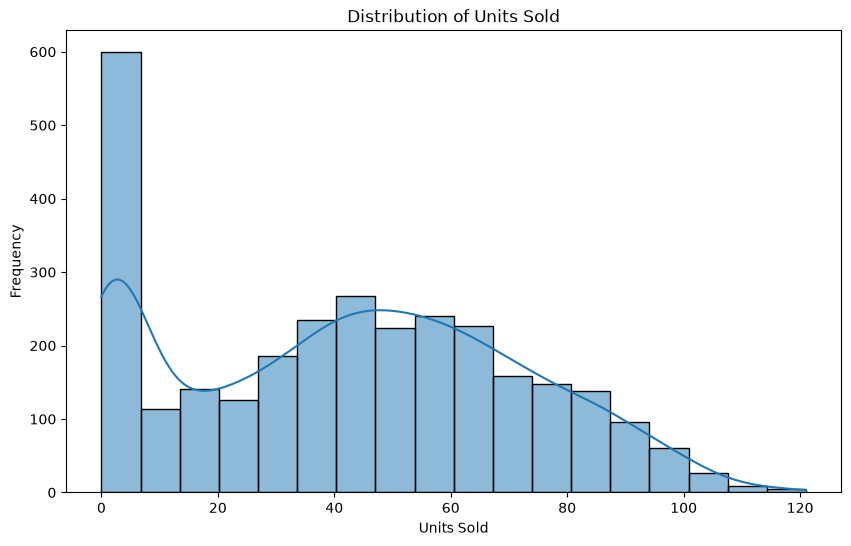

In [174]:
plt.figure(figsize=(10,6))

sns.histplot(df["Units_Sold"], kde=True)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.show()

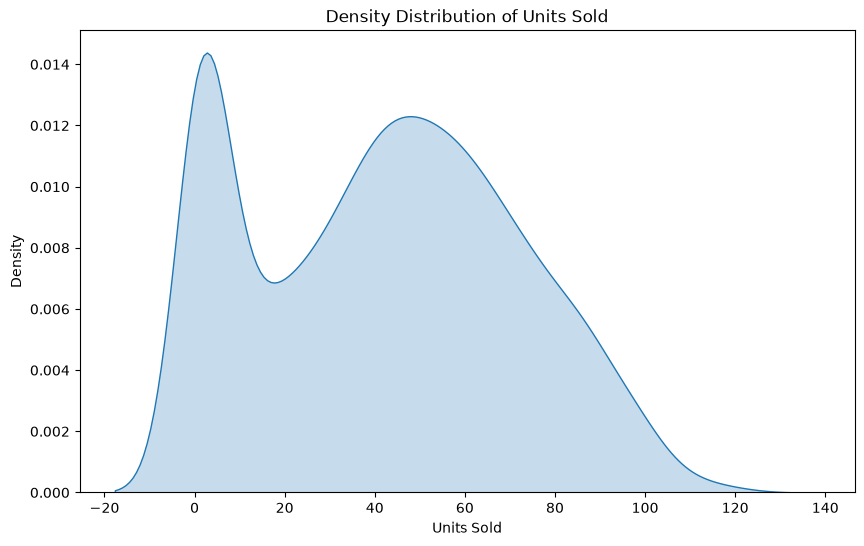

In [175]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    df["Units_Sold"],
    fill=True
)

plt.title("Density Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Density")
plt.show()

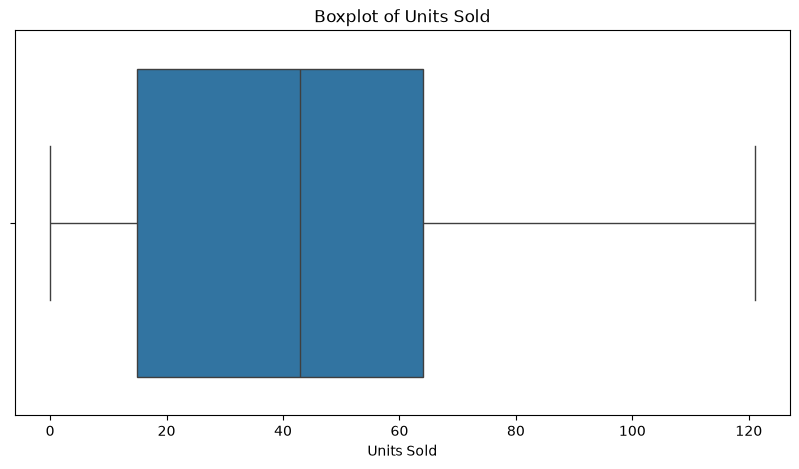

In [176]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["Units_Sold"]
)

plt.title("Boxplot of Units Sold")
plt.xlabel("Units Sold")
plt.show()

In [177]:
#Univariate Analysis
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns)

Index(['Row_ID', 'Units_Sold', 'Price', 'Discount_Percentage', 'Revenue',
       'Promotion_Flag', 'Stock_Availability', 'Holiday_Flag', 'Is_Weekend',
       'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator',
       'Marketing_Spend', 'Week_of_Year', 'Is_Weekday'],
      dtype='str')


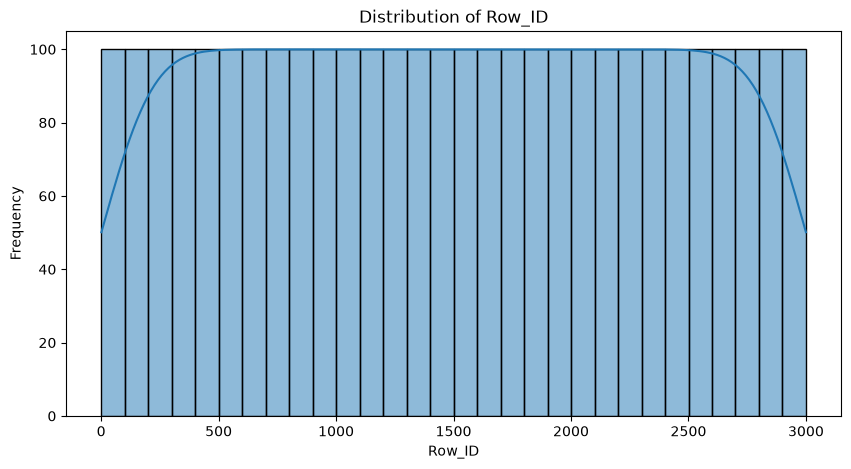

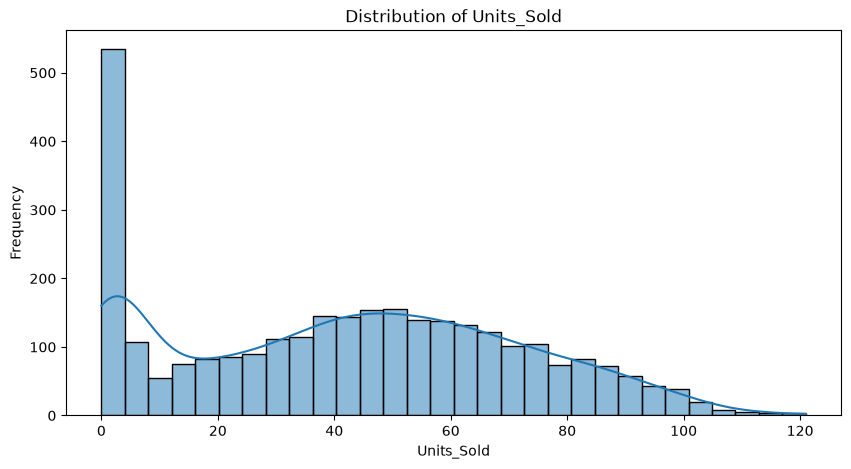

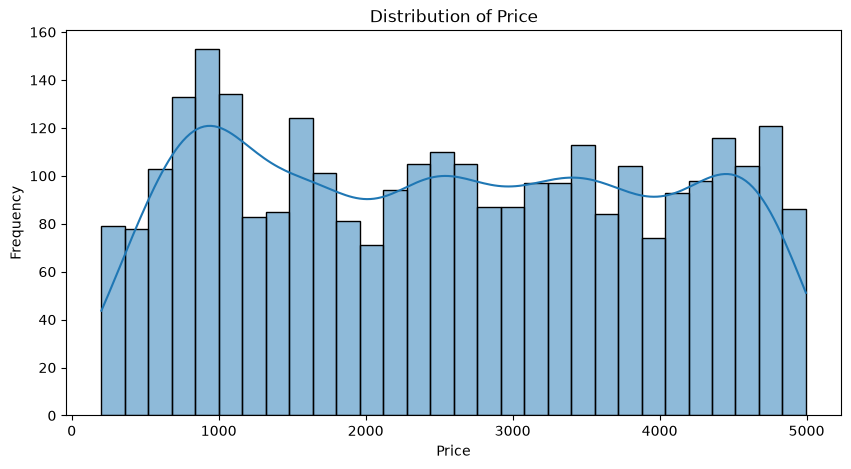

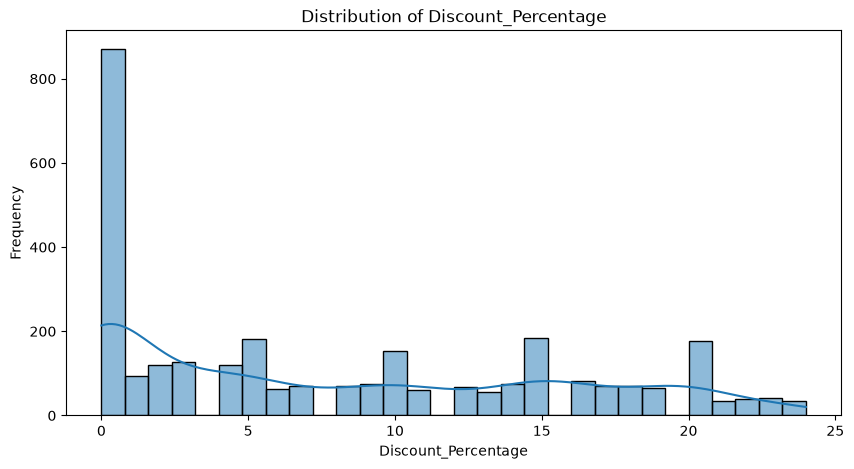

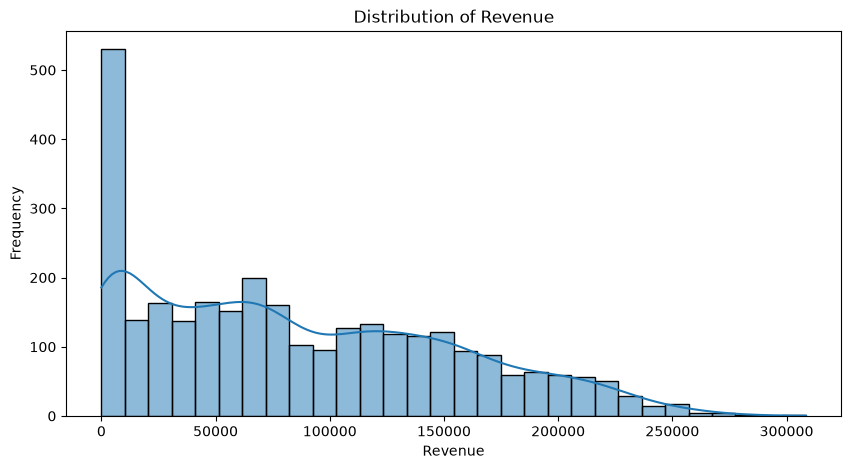

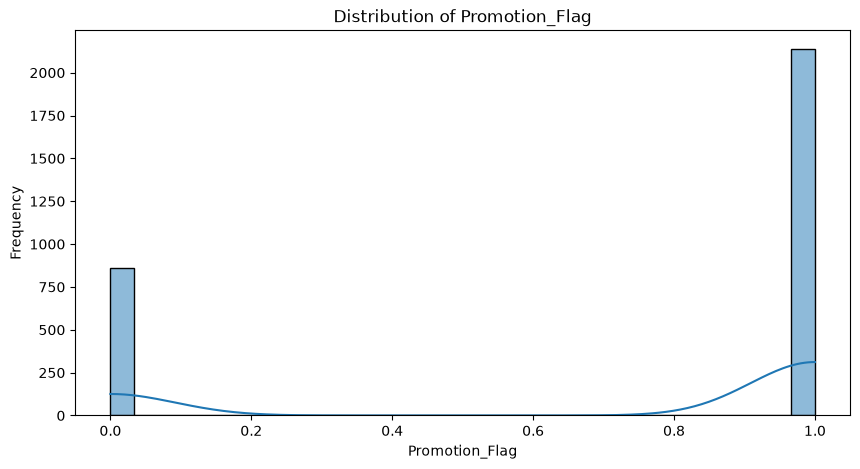

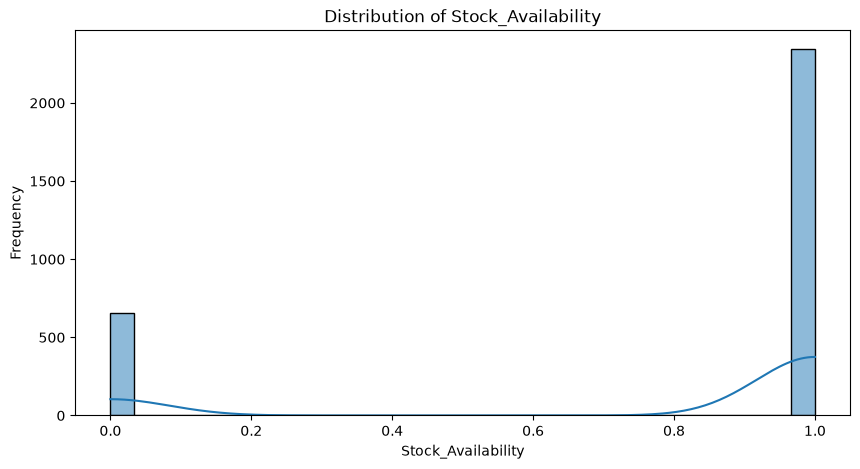

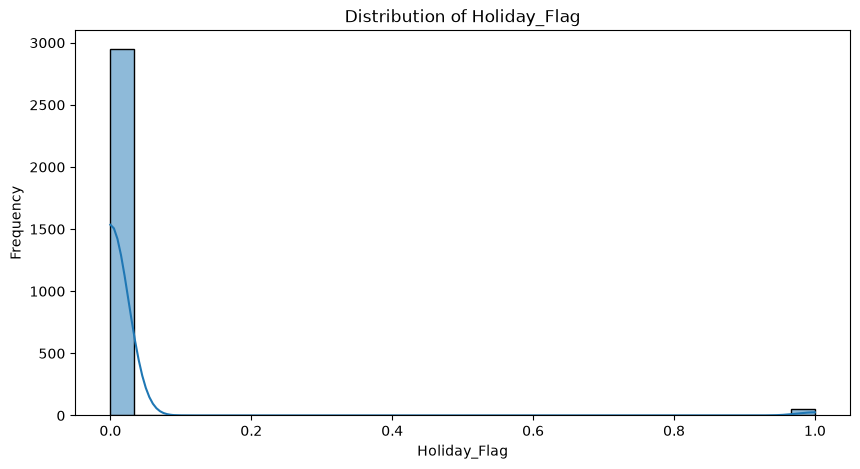

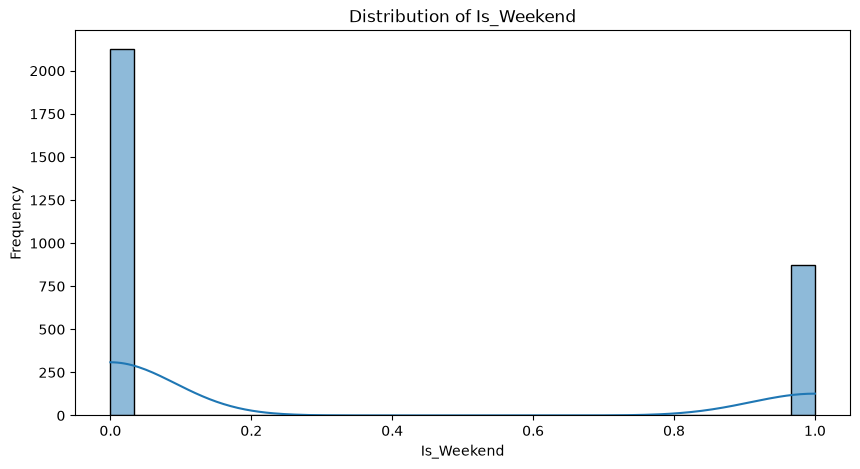

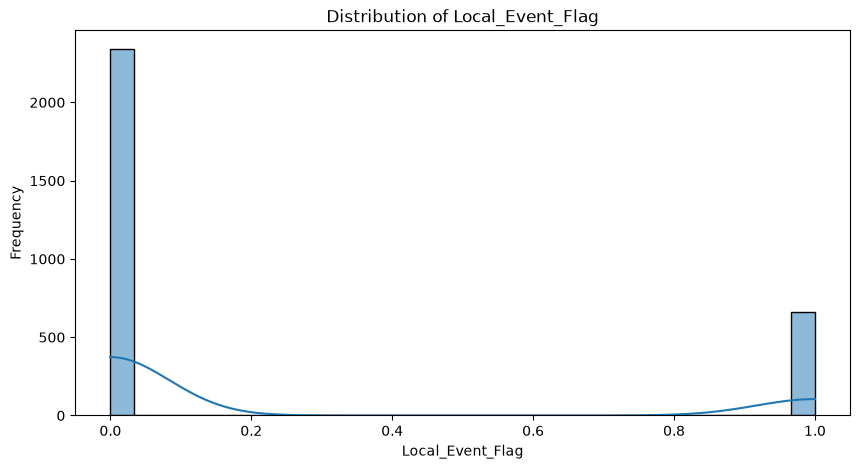

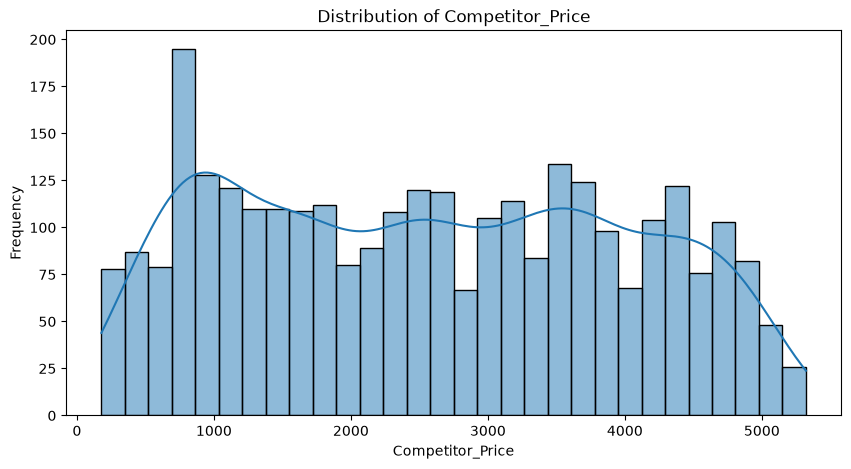

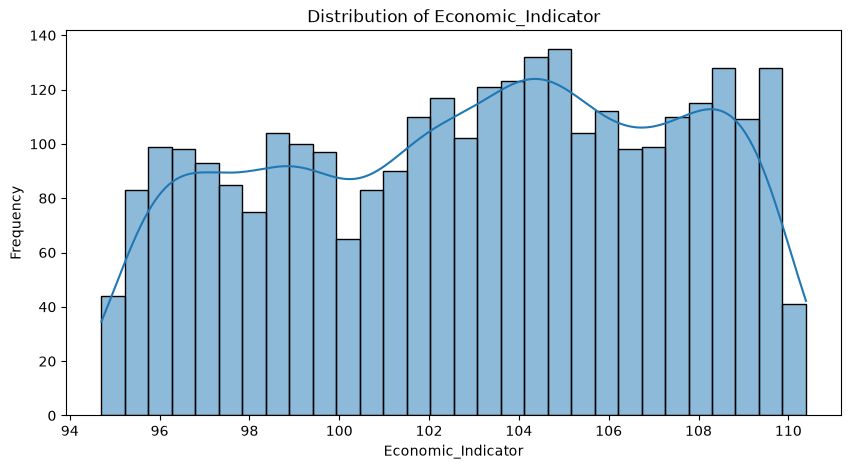

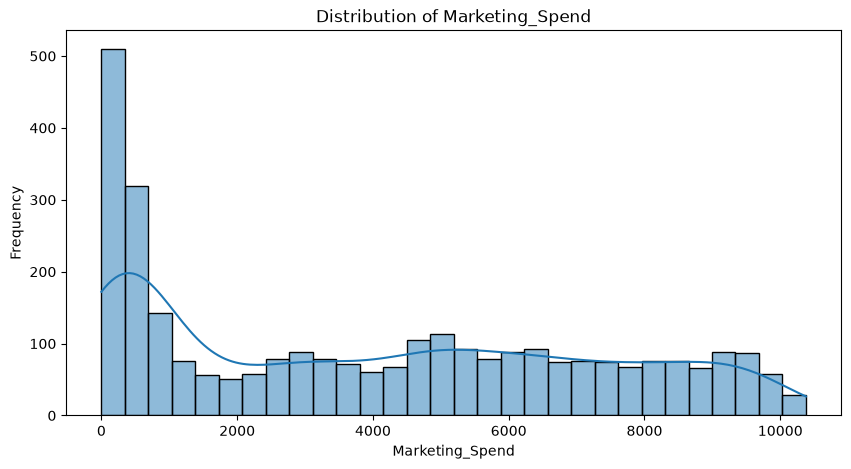

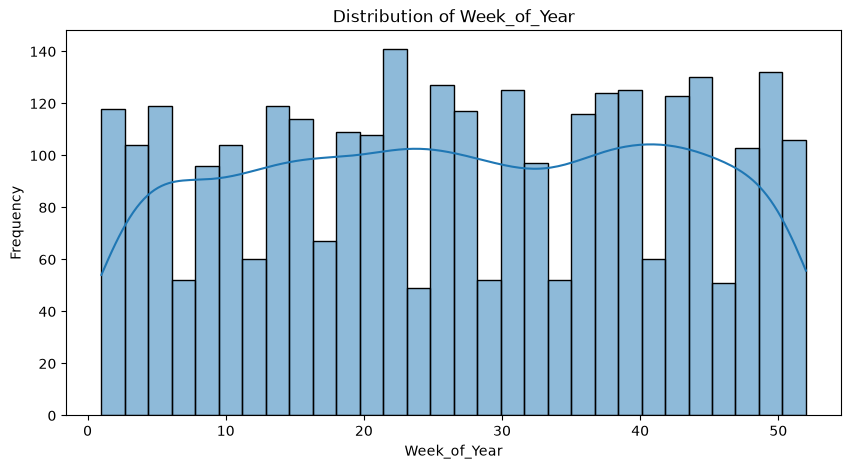

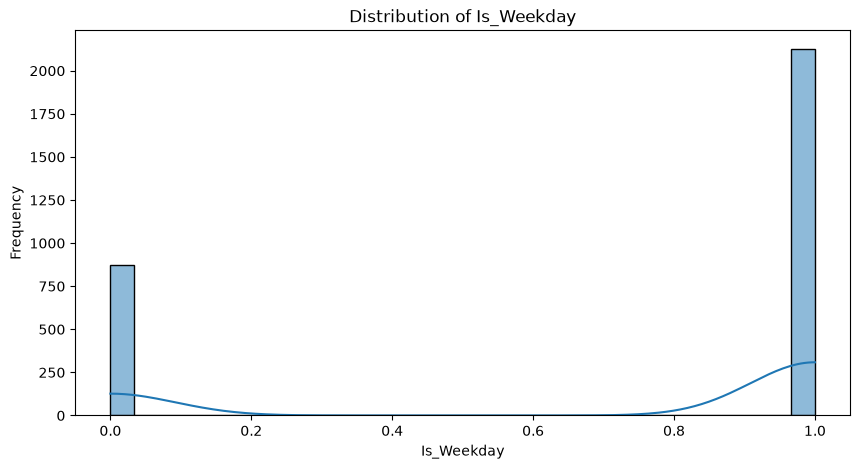

In [178]:
for col in numeric_columns:
    
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

In [179]:
#Categorical Analysis
categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location',
       'Day_of_Week', 'Month', 'Quarter', 'Holiday_Name', 'Season', 'Weather',
       'Sales_Channel', 'Customer_Segment'],
      dtype='str')


C:\Users\Nandhakumar\AppData\Local\Temp\ipykernel_7608\1974299799.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


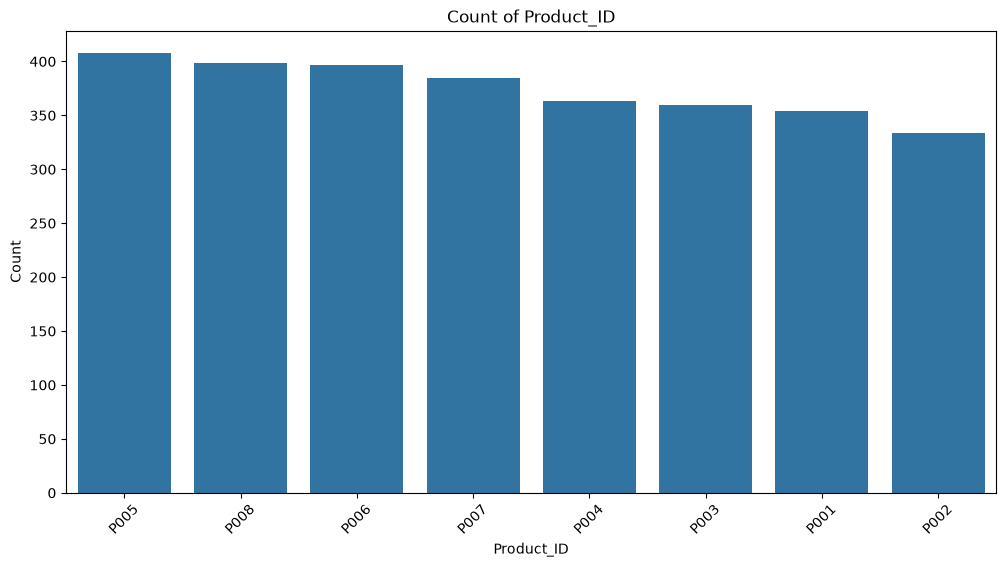

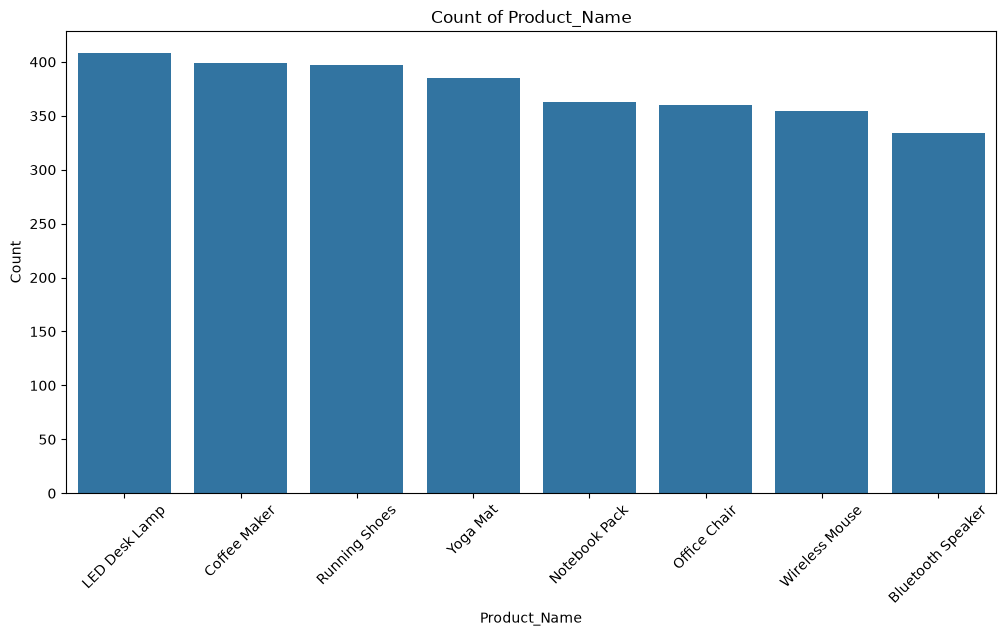

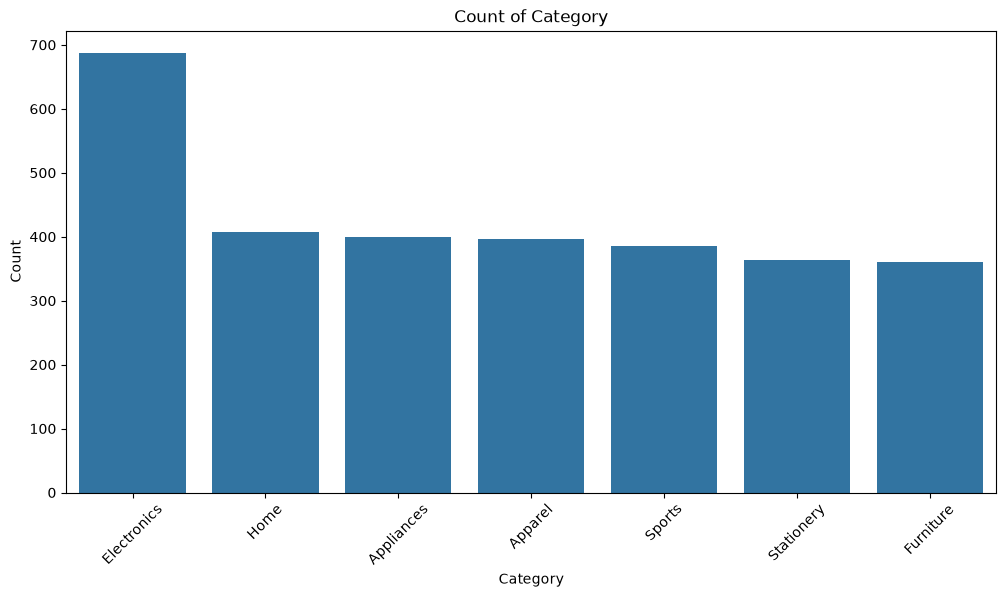

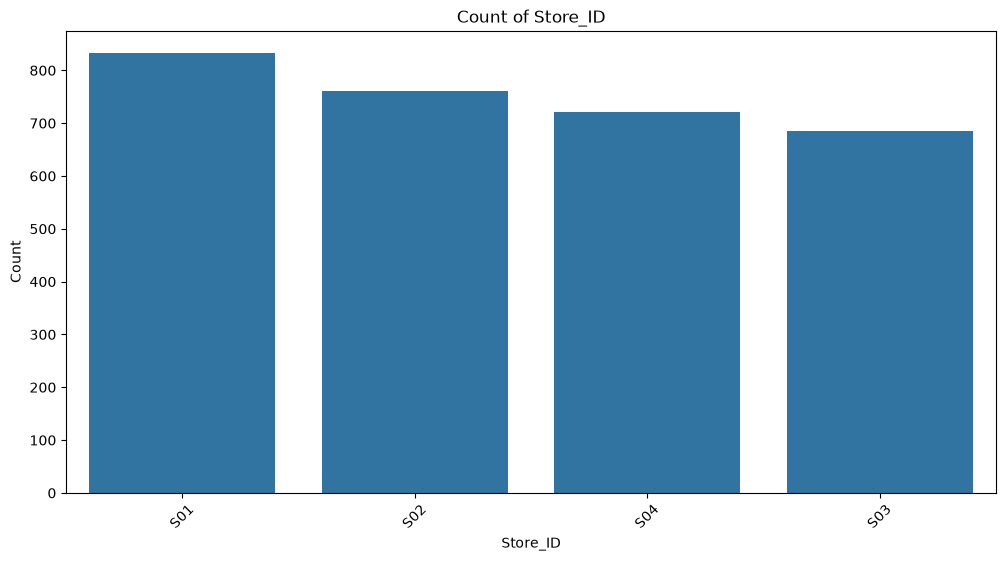

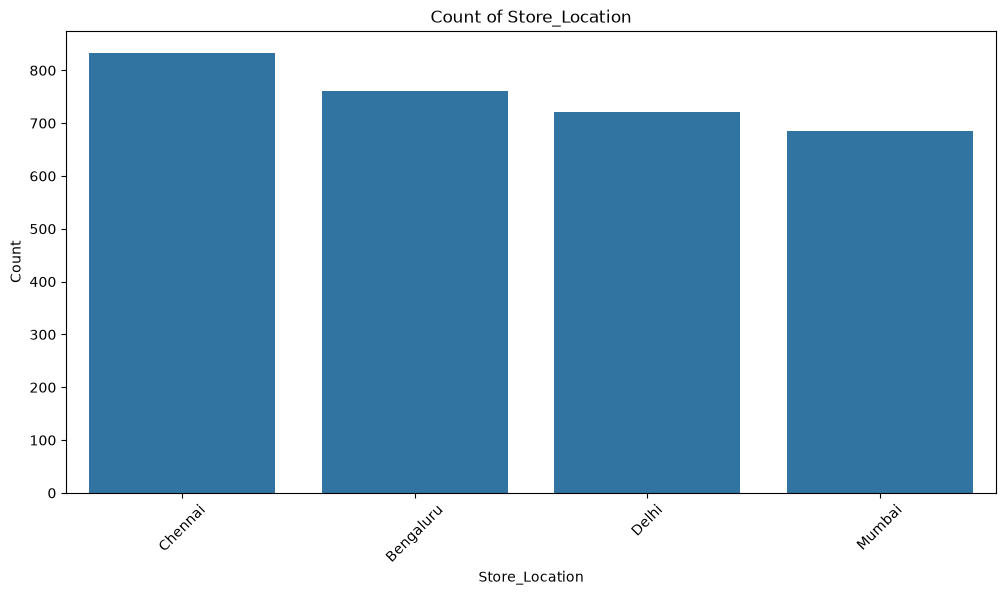

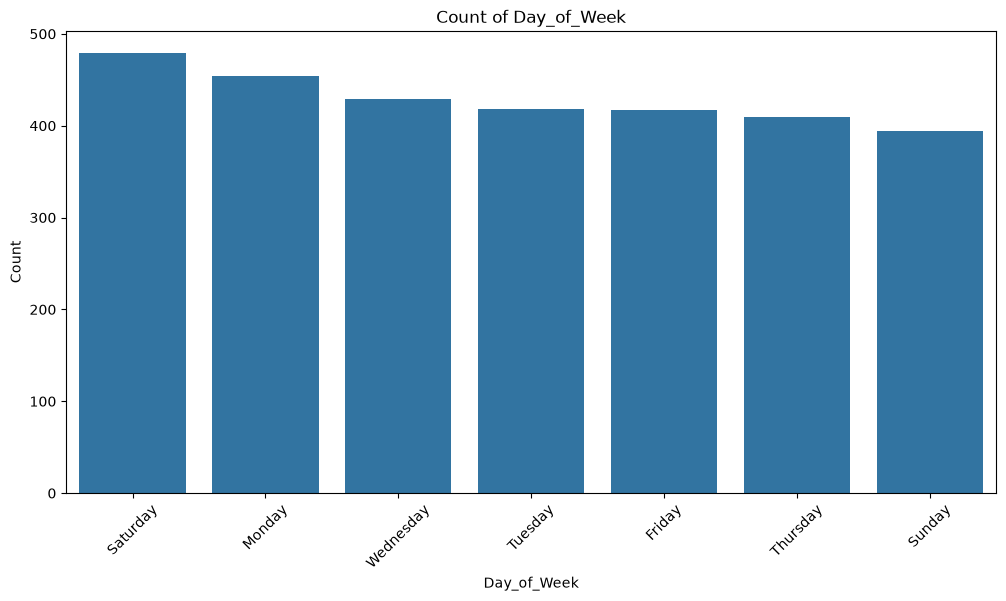

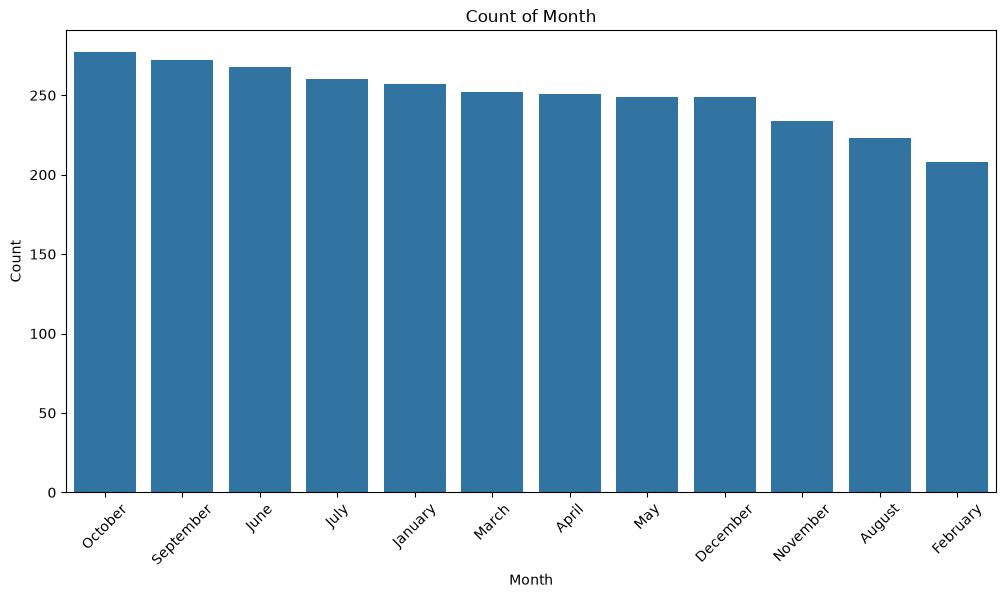

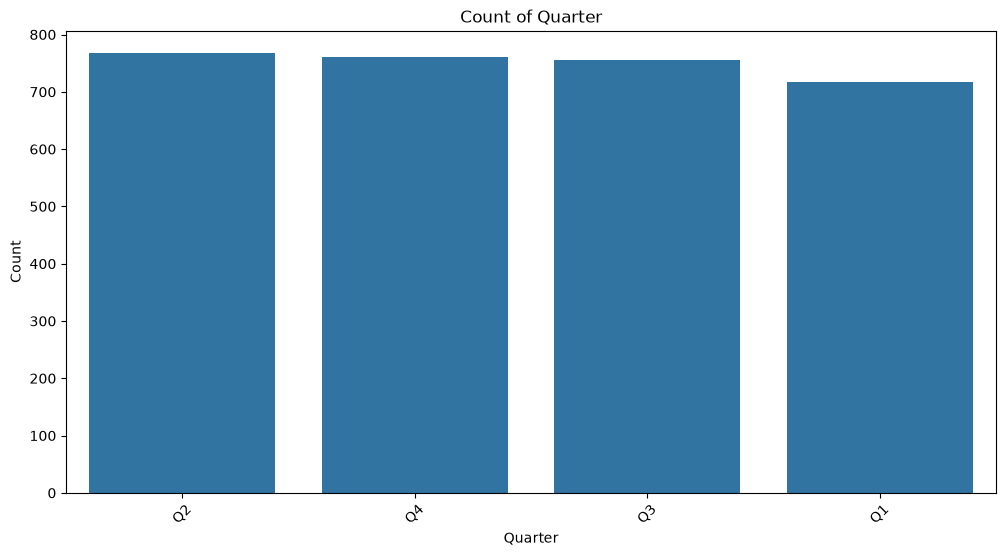

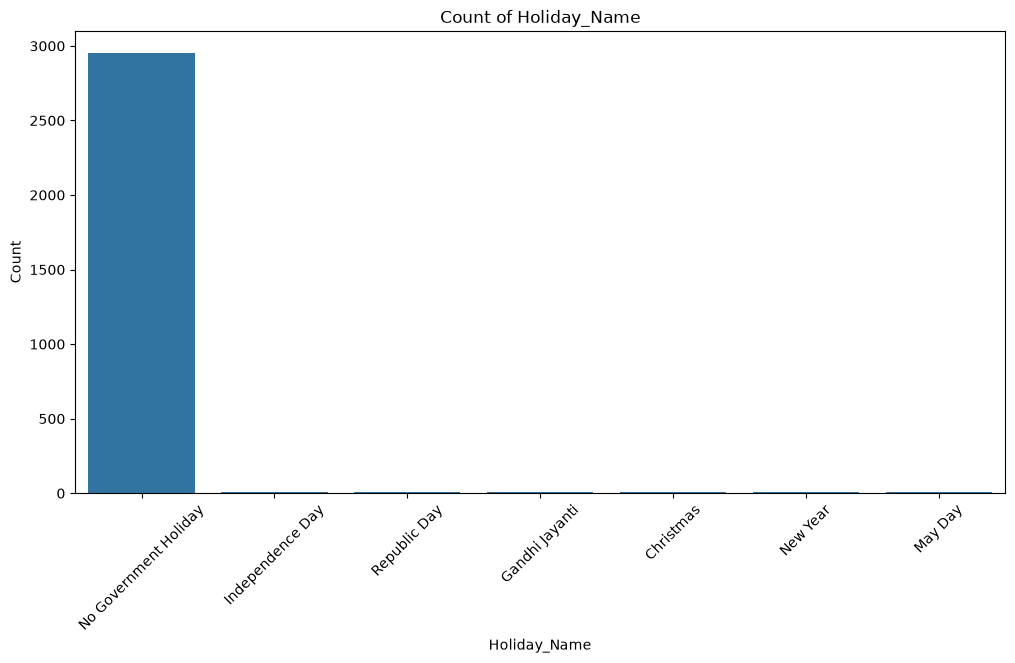

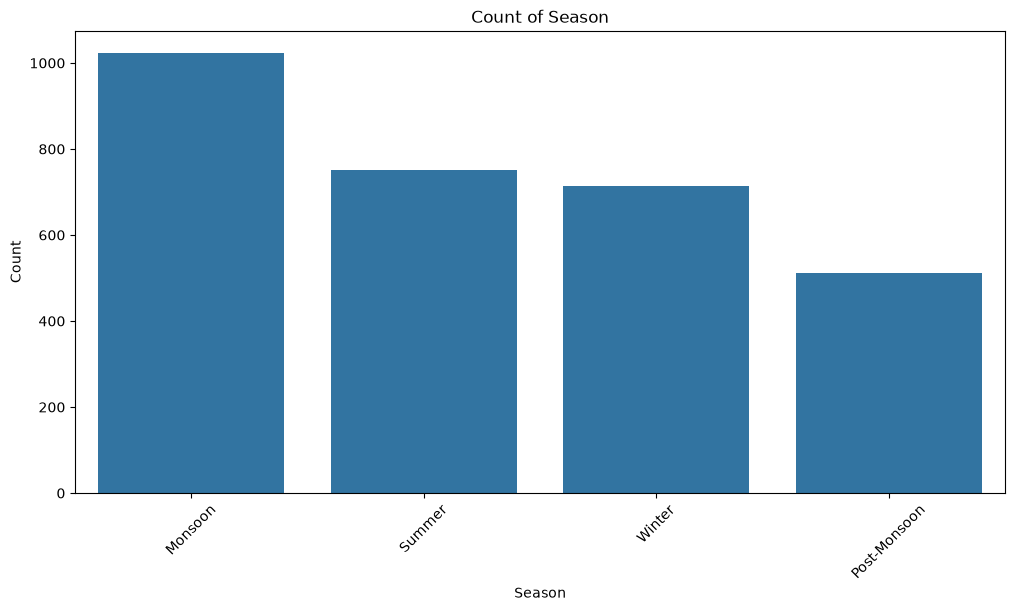

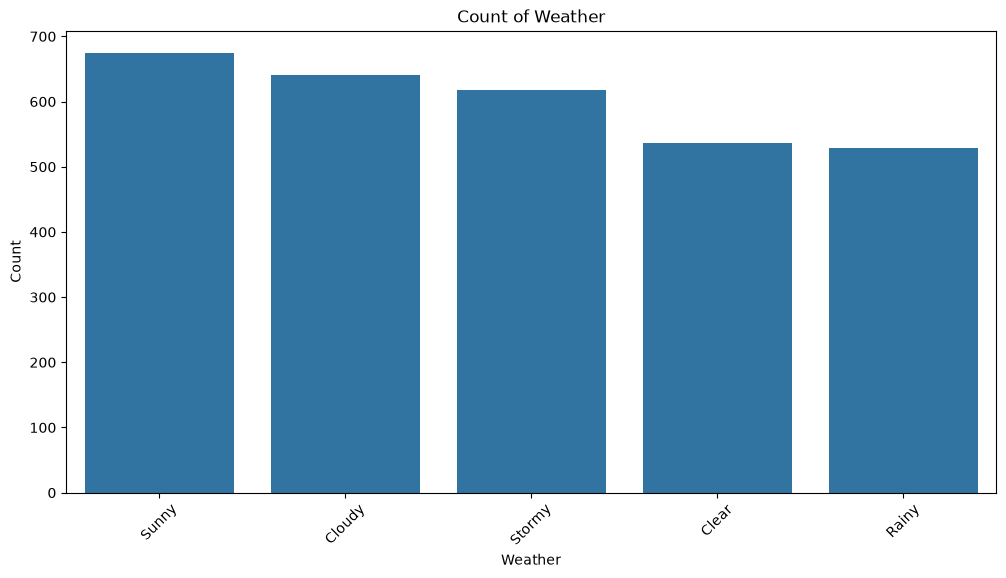

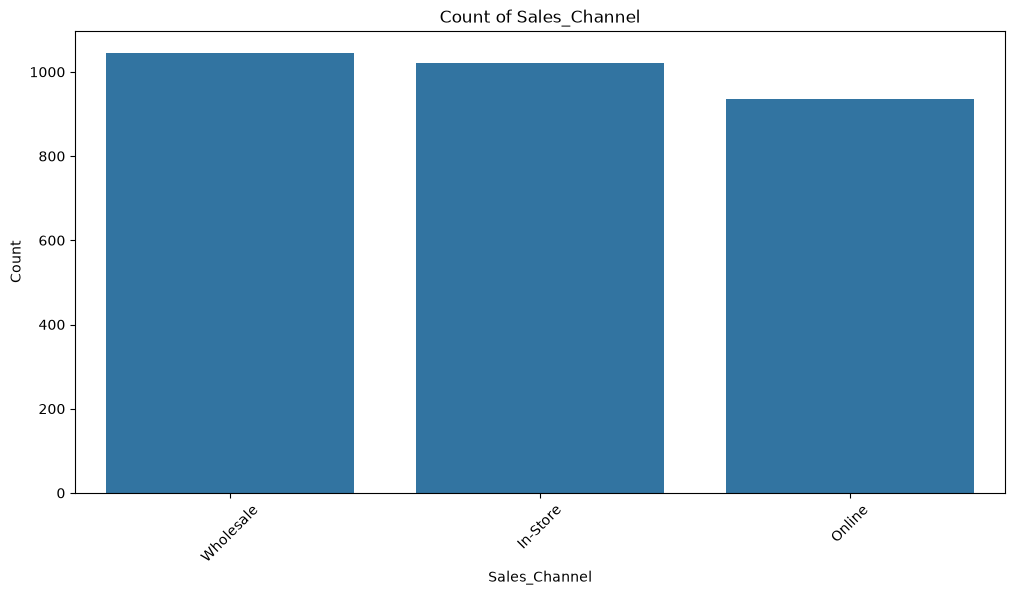

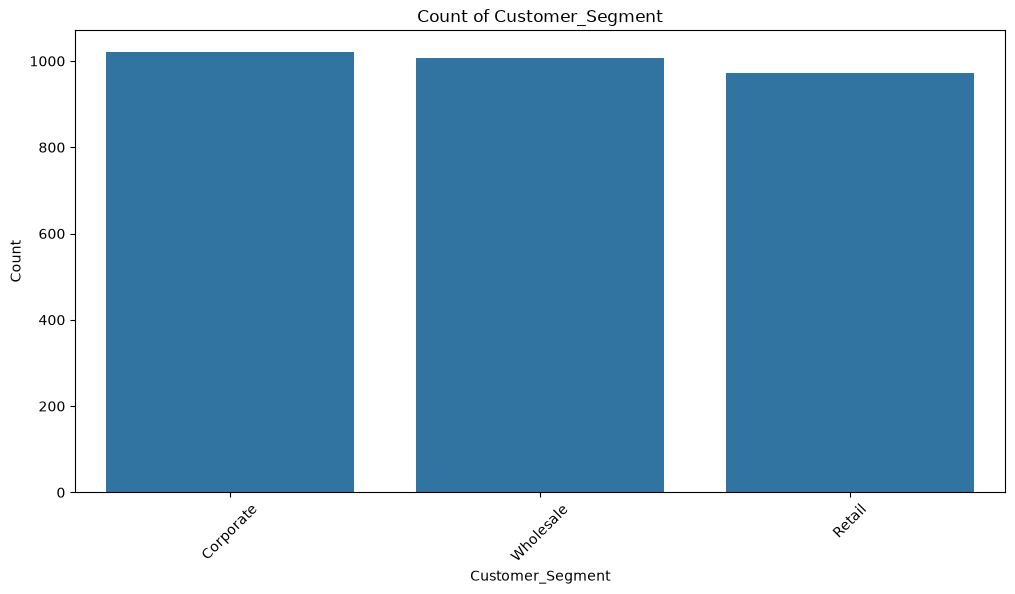

In [180]:
for col in categorical_columns:
    
    plt.figure(figsize=(12, 6))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45)
    plt.show()

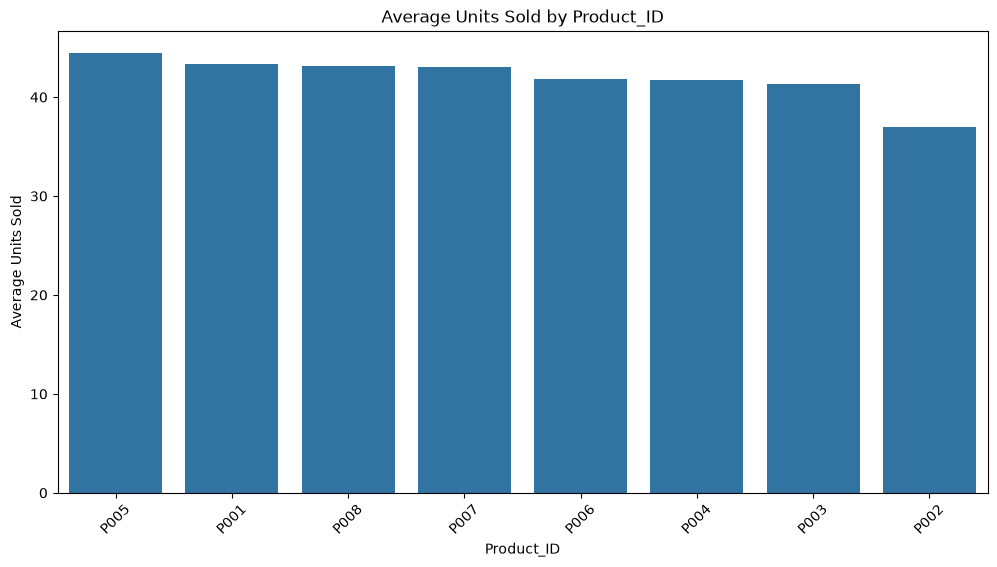

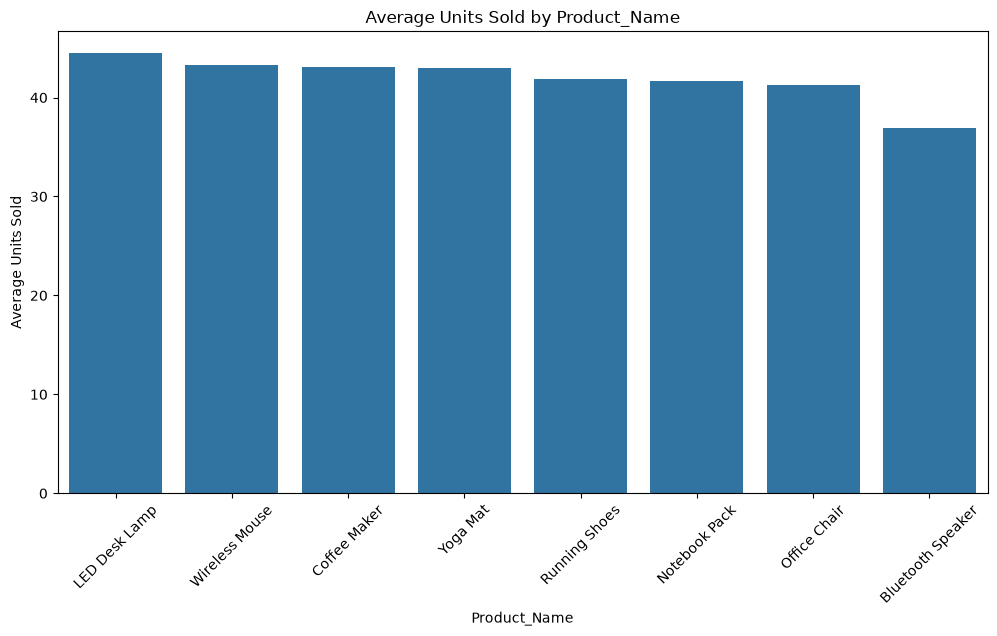

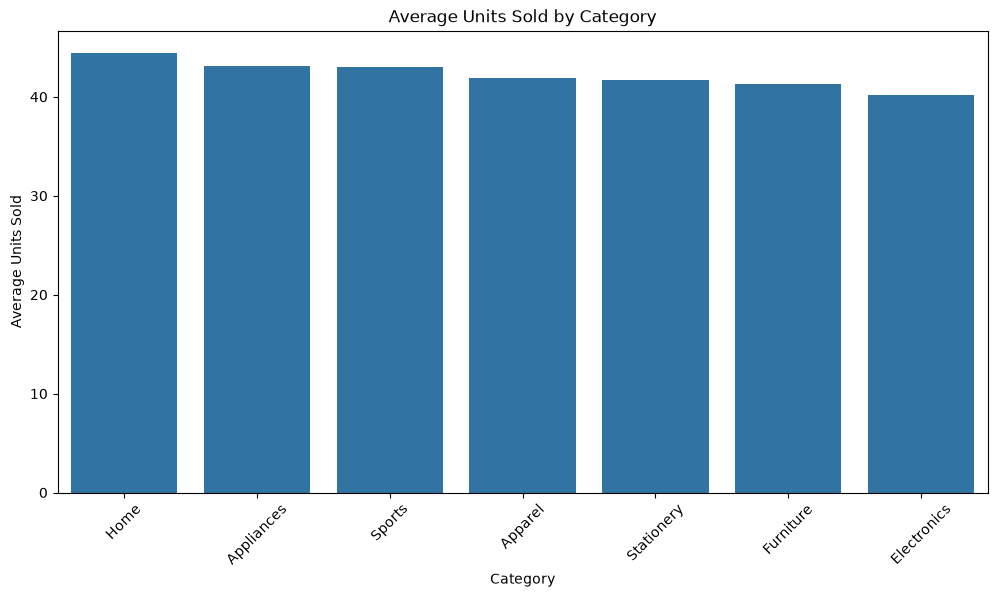

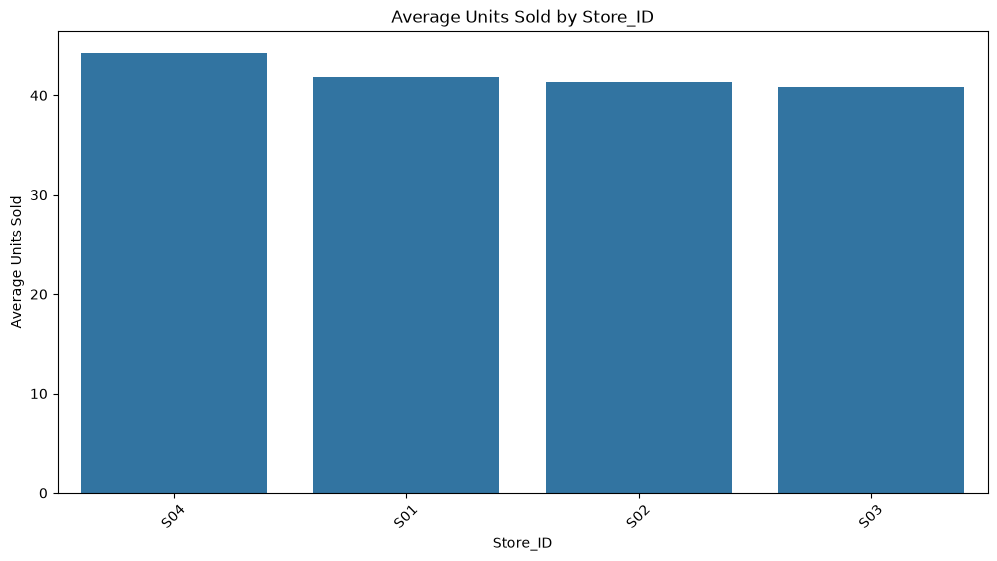

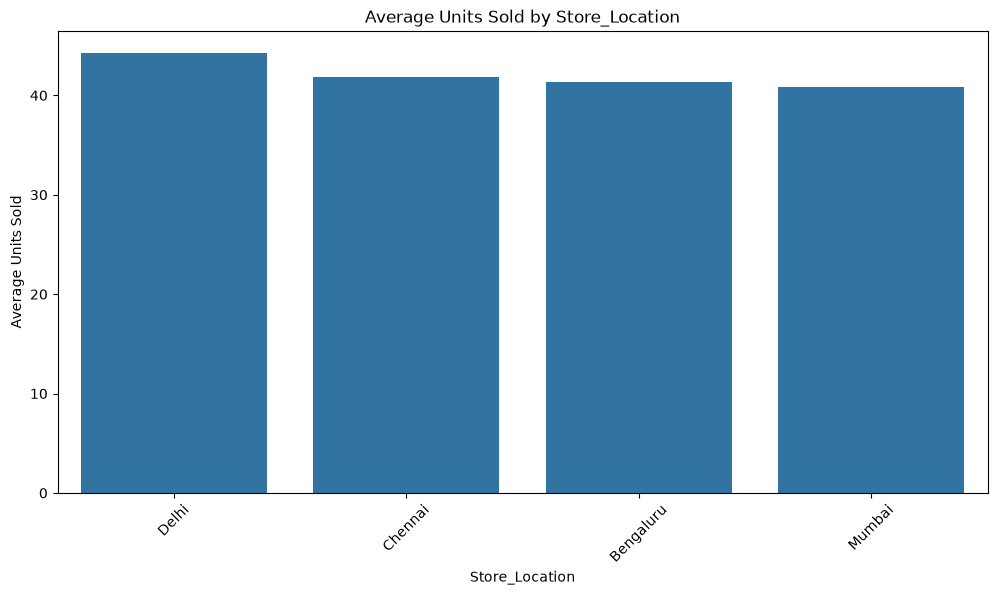

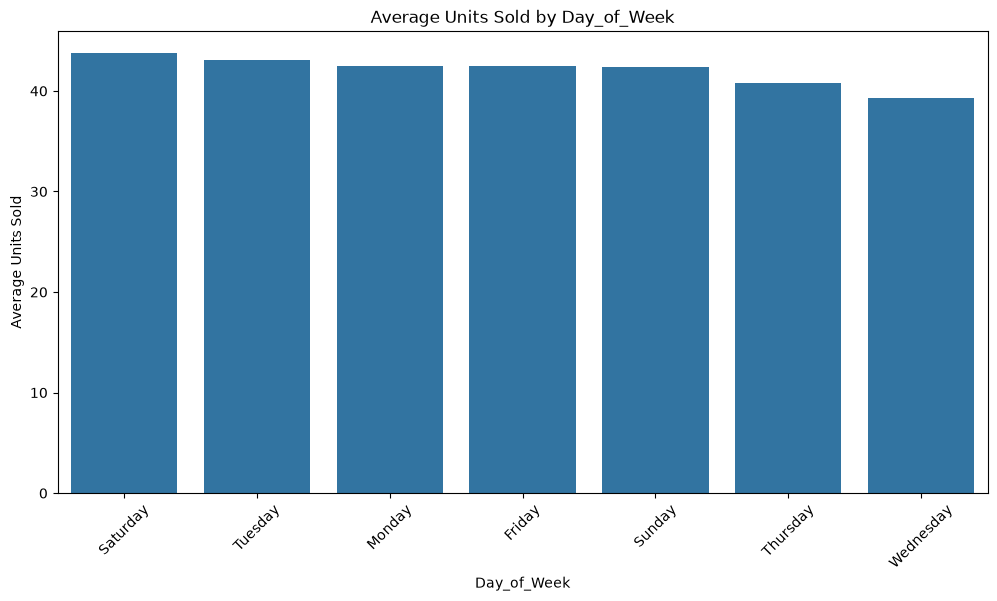

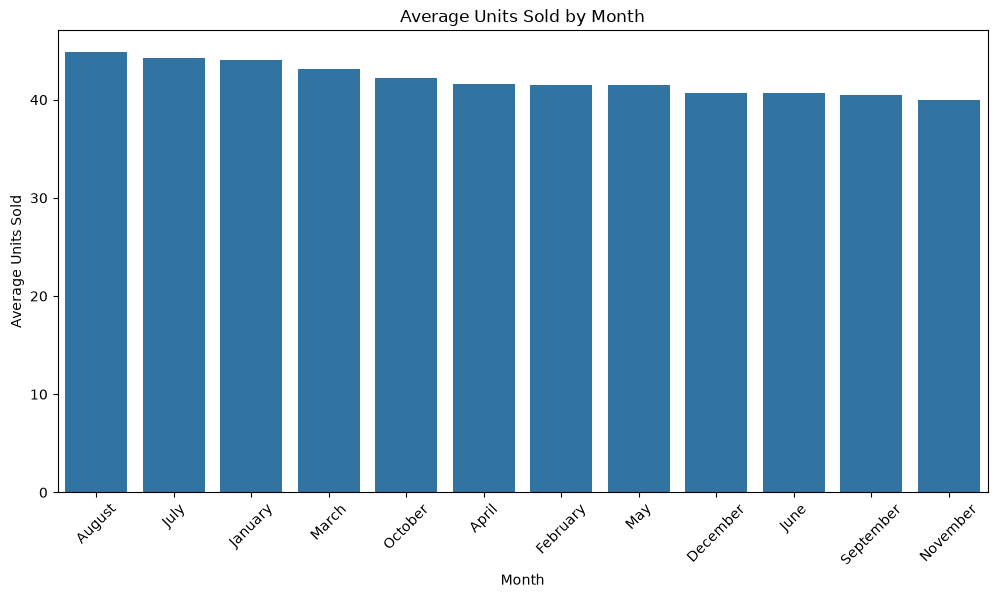

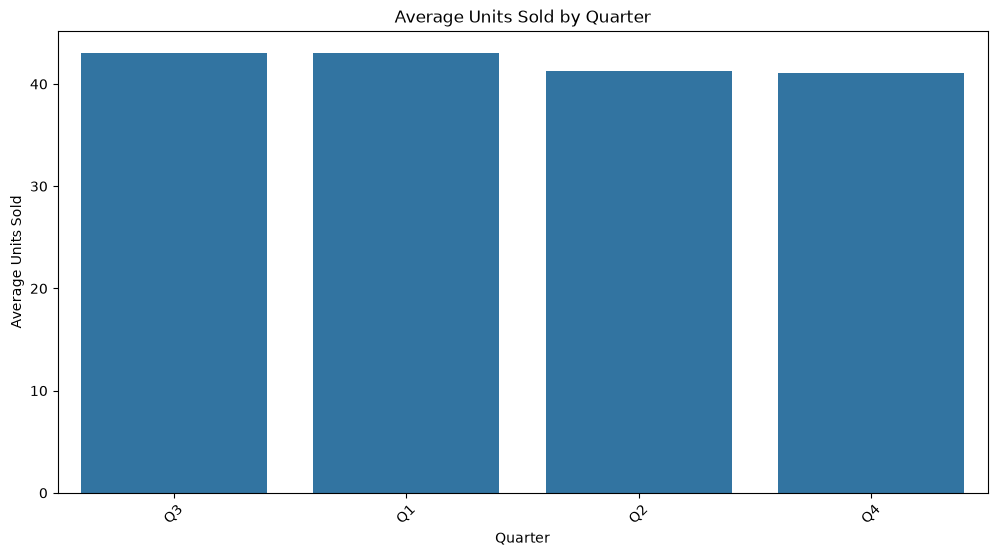

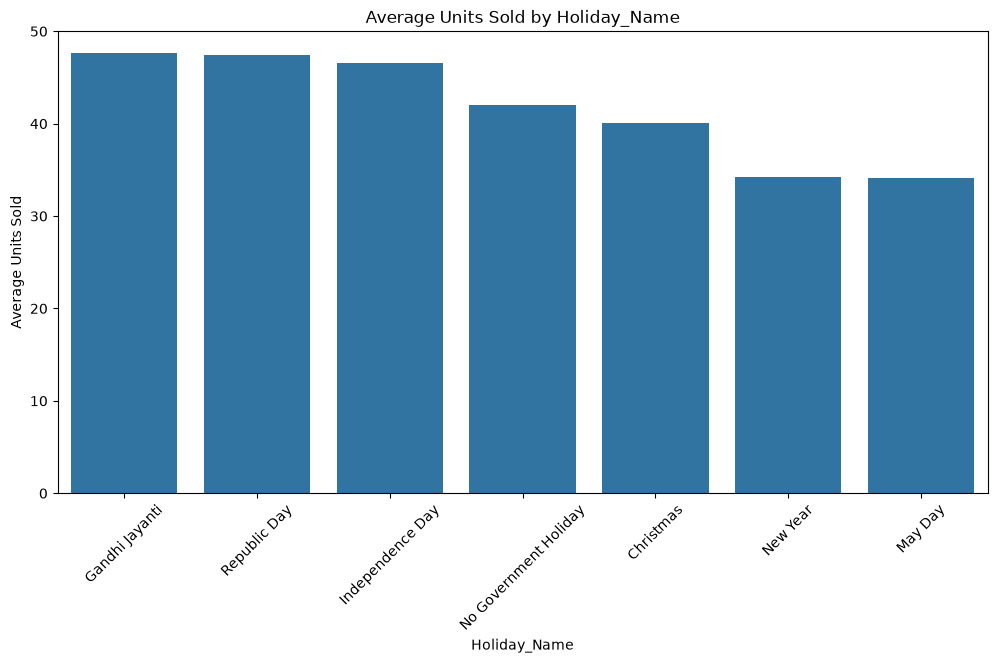

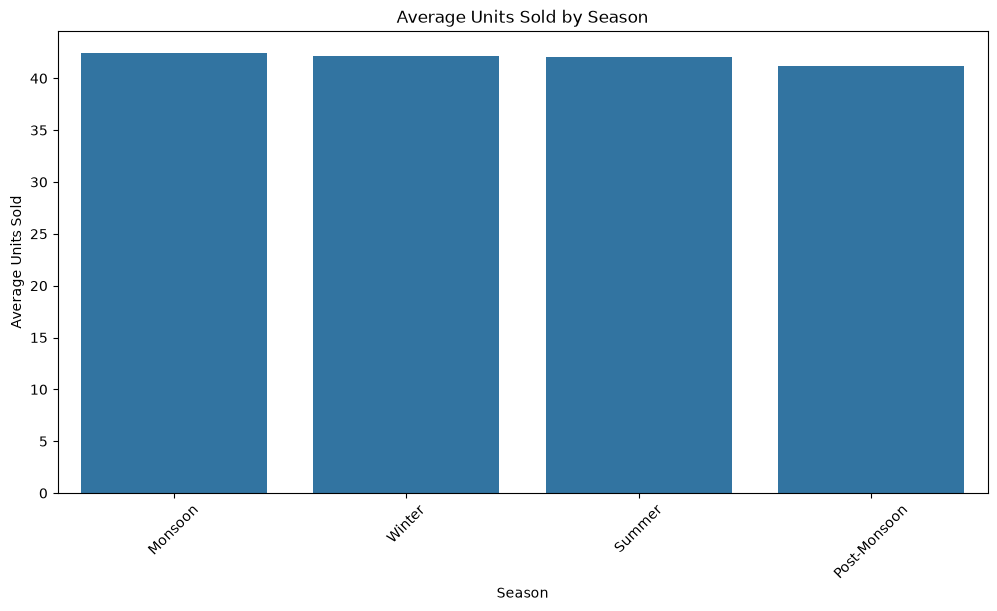

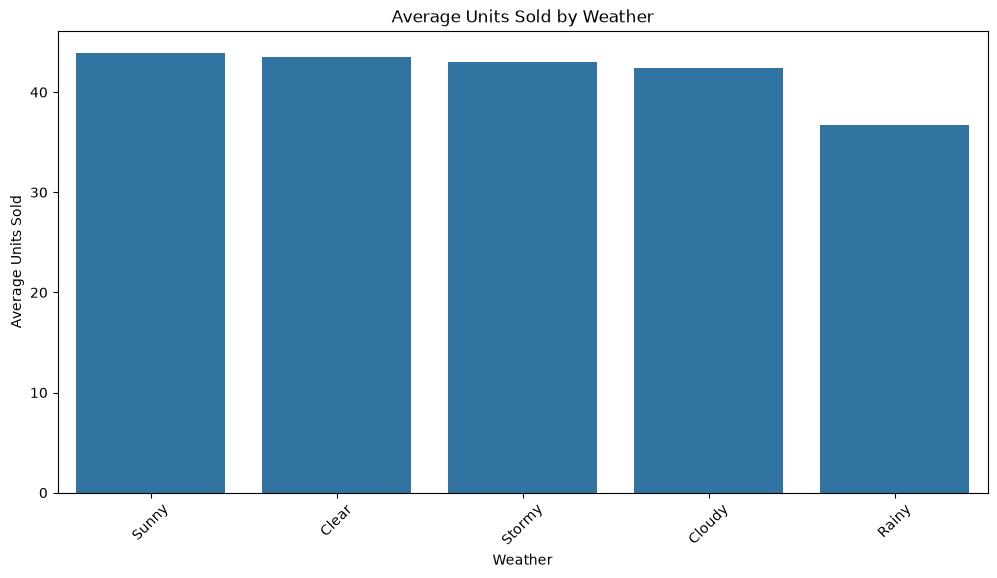

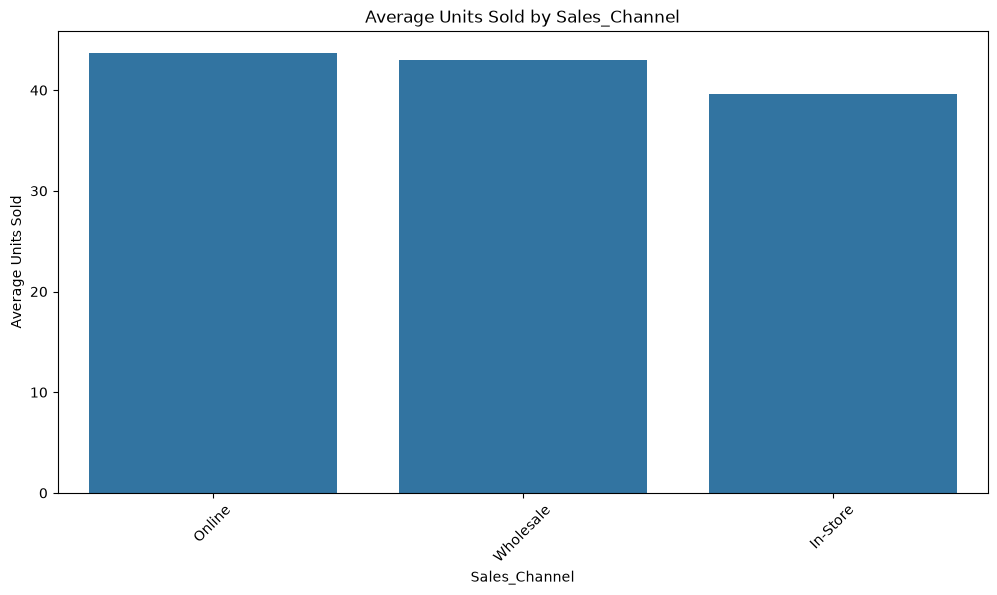

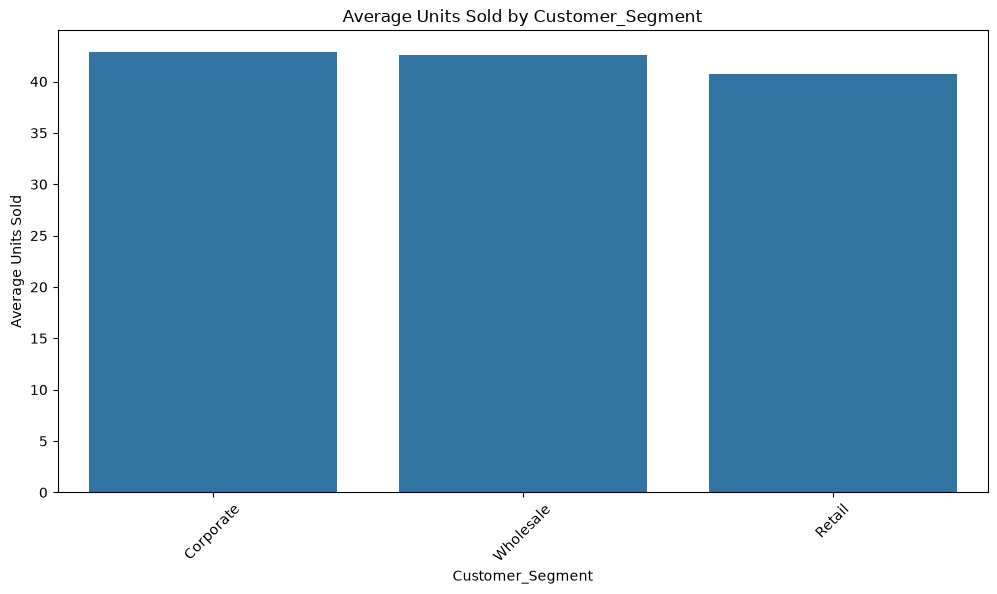

In [181]:
#Categorical Variables vs Units_Sold
for col in categorical_columns:
    
    plt.figure(figsize=(12, 6))
    
    category_sales = (
        df.groupby(col)["Units_Sold"]
        .mean()
        .sort_values(ascending=False)
    )
    
    sns.barplot(
        x=category_sales.index,
        y=category_sales.values
    )
    
    plt.title(f"Average Units Sold by {col}")
    plt.xlabel(col)
    plt.ylabel("Average Units Sold")
    
    plt.xticks(rotation=45)
    plt.show()

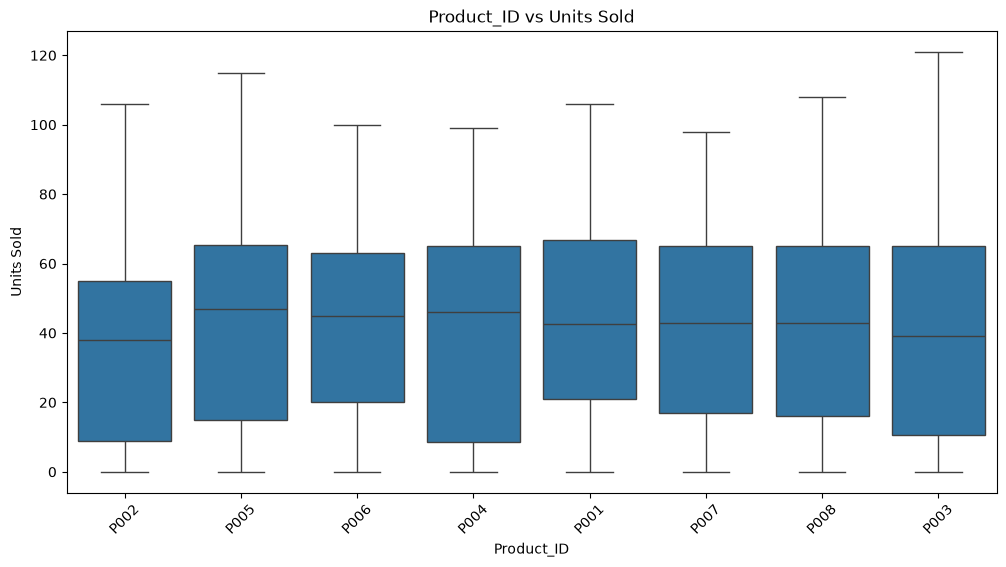

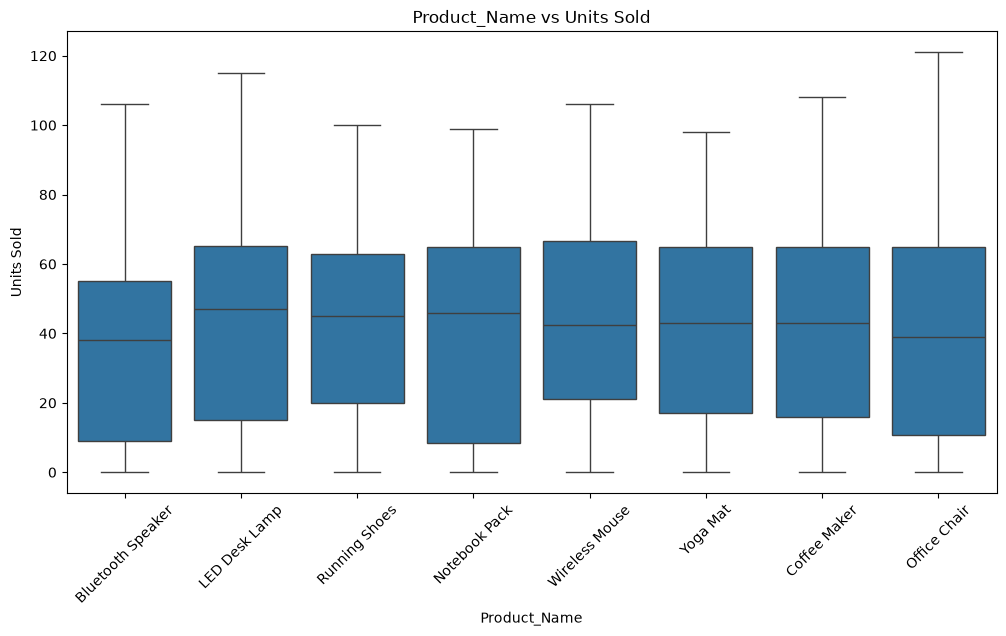

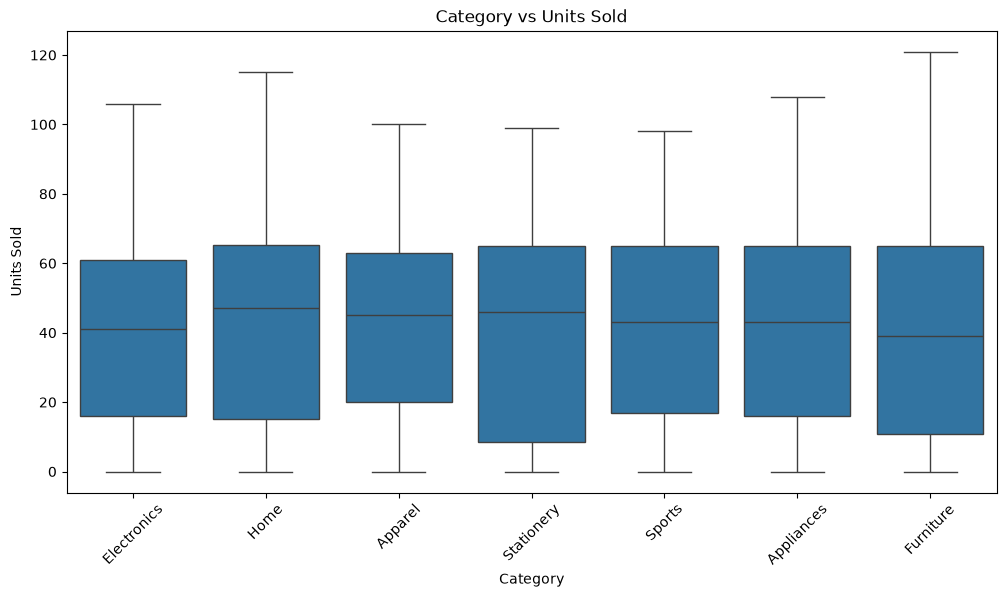

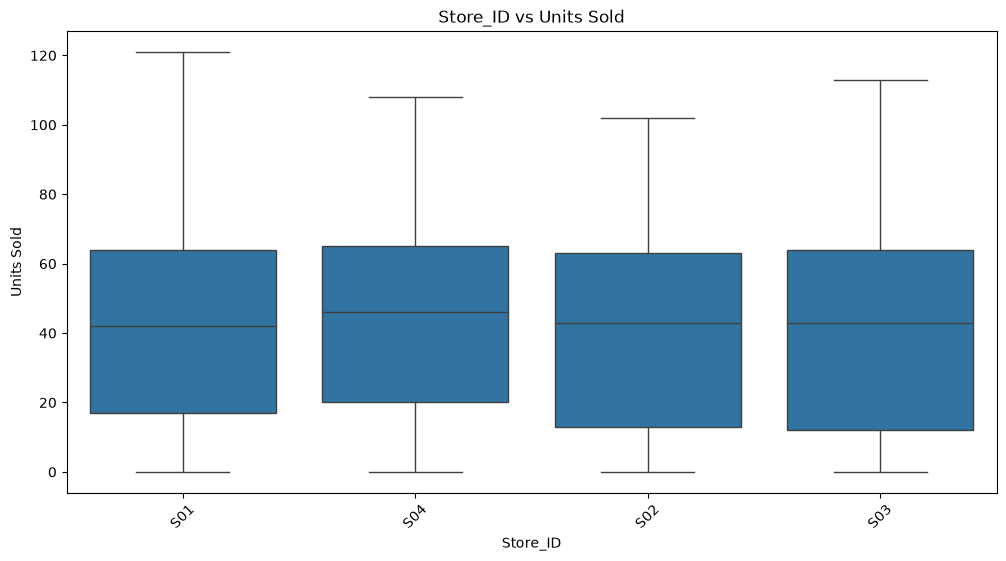

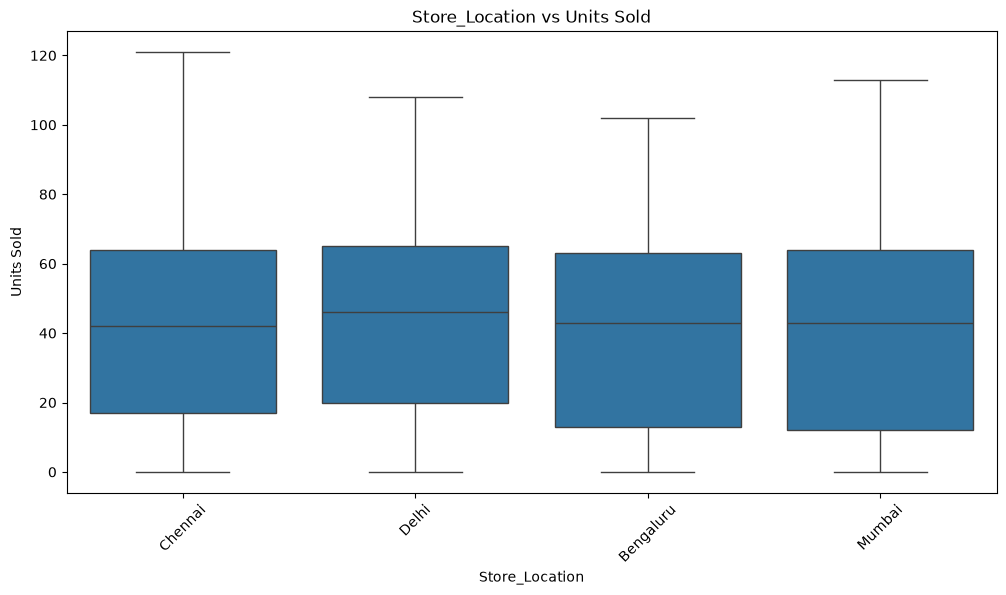

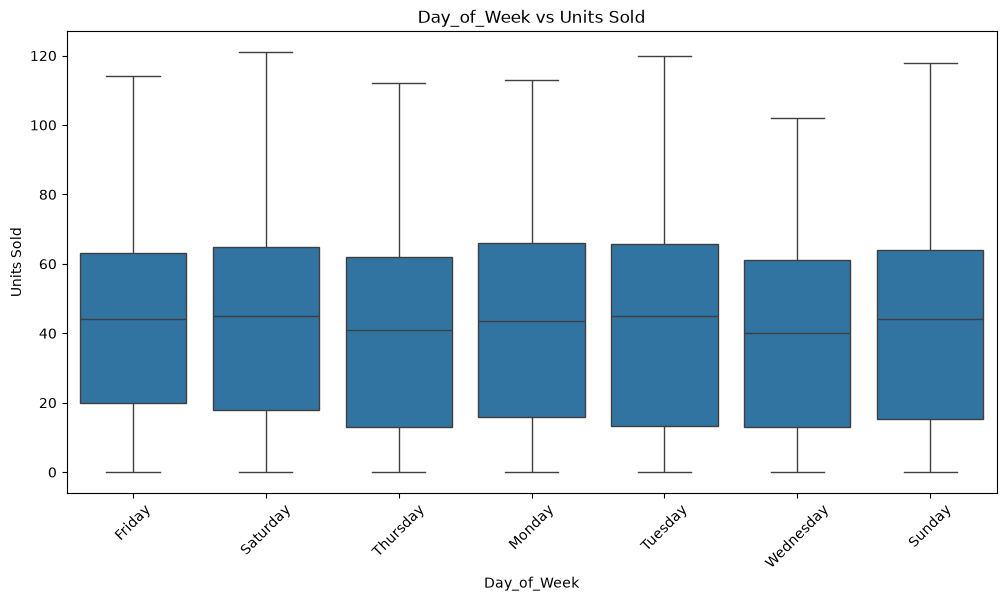

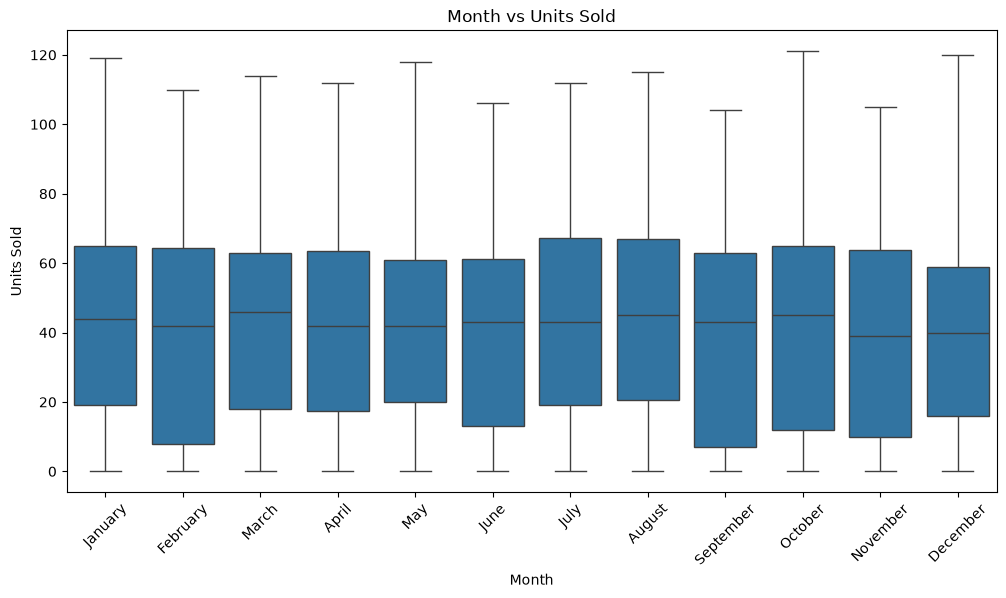

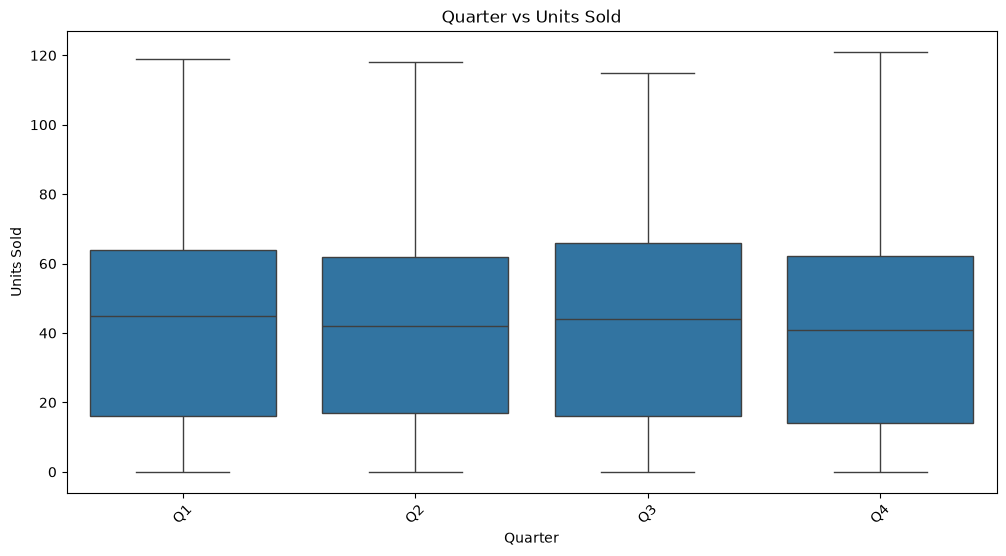

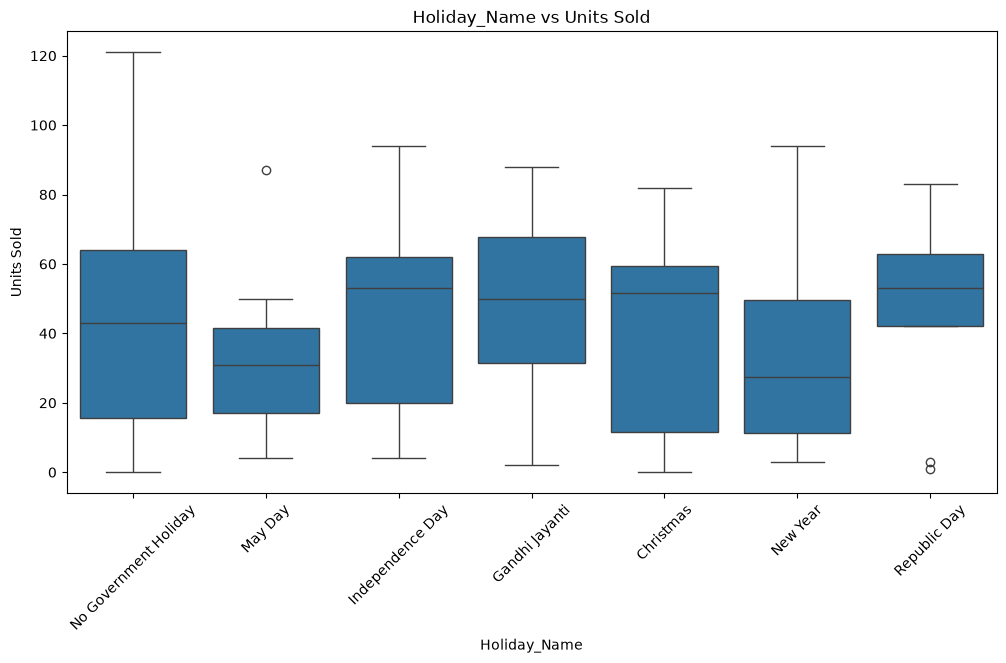

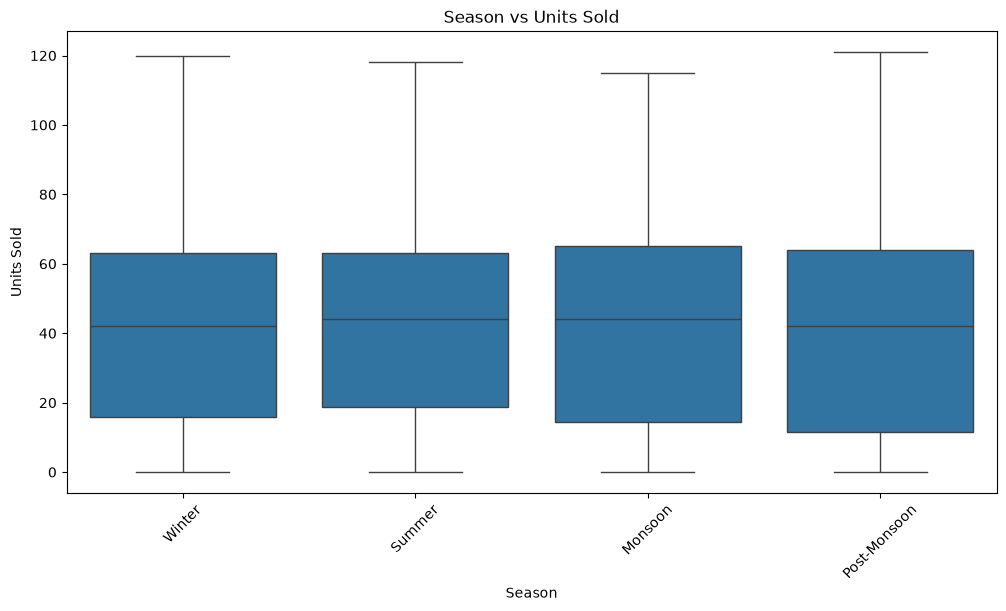

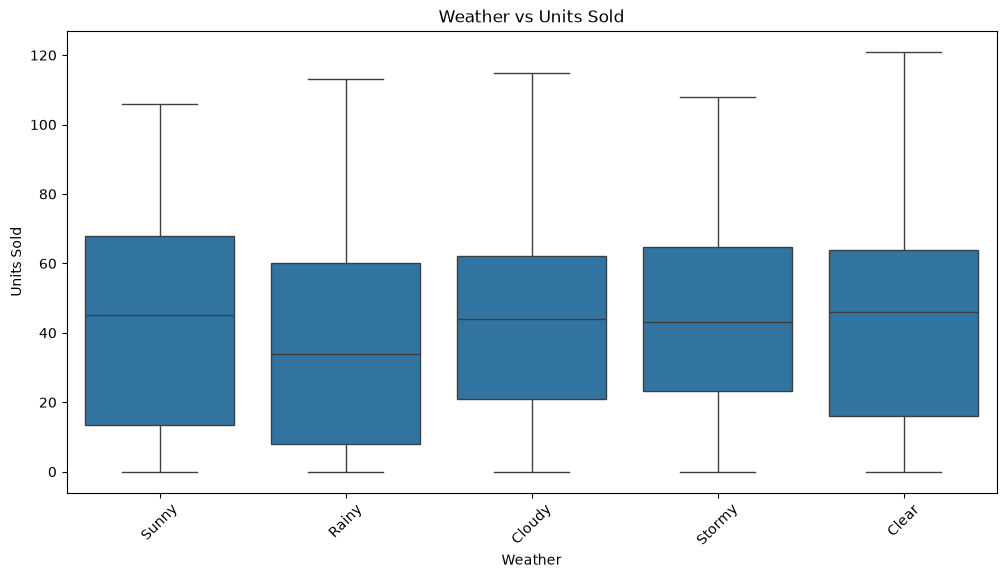

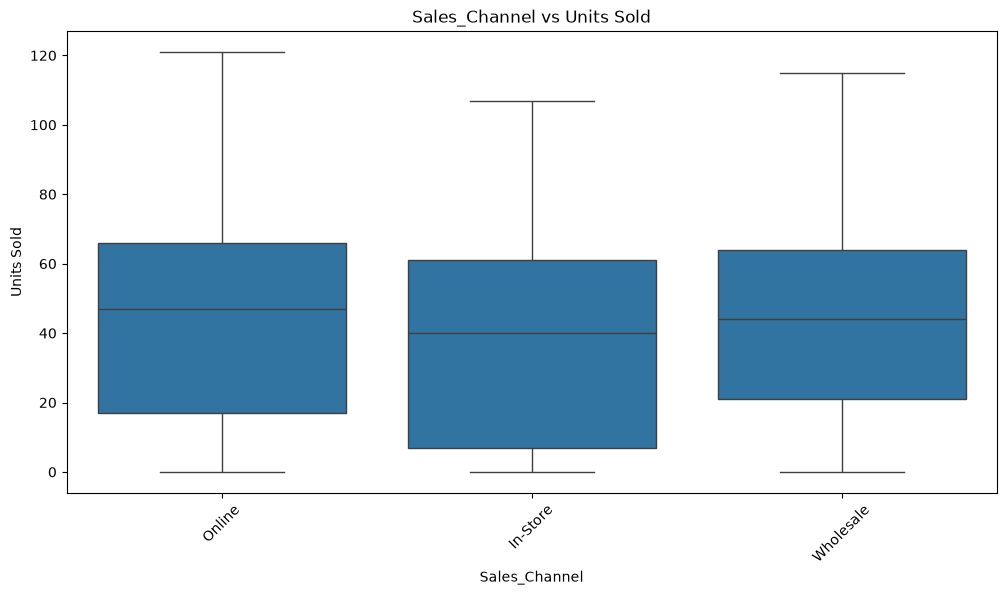

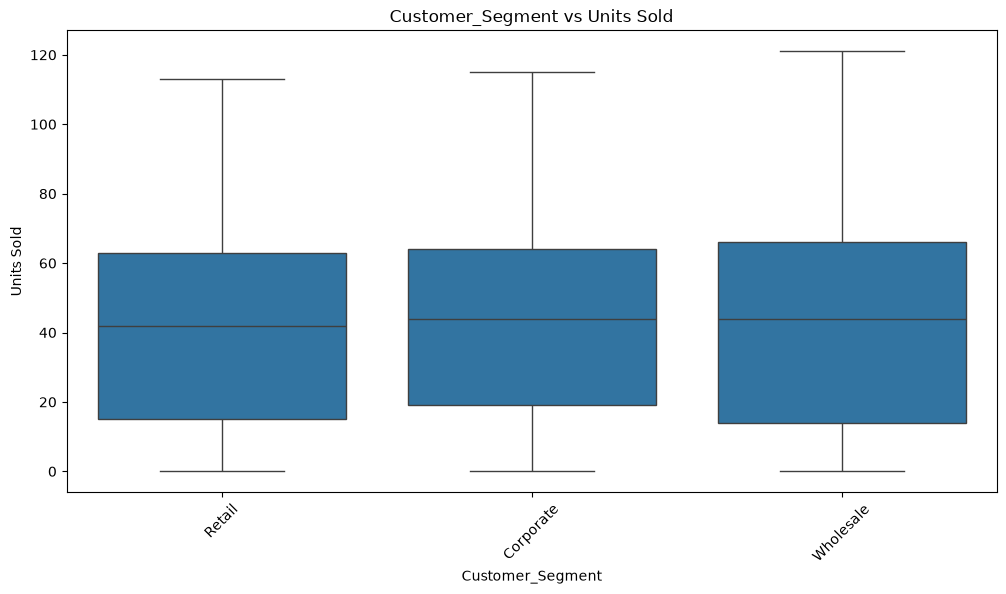

In [182]:
for col in categorical_columns:
    
    plt.figure(figsize=(12, 6))
    
    sns.boxplot(
        data=df,
        x=col,
        y="Units_Sold"
    )
    
    plt.title(f"{col} vs Units Sold")
    plt.xlabel(col)
    plt.ylabel("Units Sold")
    
    plt.xticks(rotation=45)
    plt.show()

In [183]:
#Correlation Analysis
correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

correlation_matrix

,Row_ID,Units_Sold,Price,Discount_Percentage,Revenue,Promotion_Flag,Stock_Availability,Holiday_Flag,Is_Weekend,Local_Event_Flag,Competitor_Price,Economic_Indicator,Marketing_Spend,Week_of_Year,Is_Weekday
Row_ID,1.000000,-0.054543,-0.033564,-0.022577,-0.043146,0.002804,-0.030618,0.000572,-0.022653,-0.071683,-0.031972,-0.022263,-0.052601,0.095641,0.022653
Units_Sold,-0.054543,1.000000,-0.306506,0.416296,0.568104,0.383766,0.693741,-0.000033,0.023689,0.153969,-0.309005,-0.027352,0.269368,-0.020770,-0.023689
Price,-0.033564,-0.306506,1.000000,0.073965,0.453810,0.063274,0.021222,0.012310,0.014521,0.041975,0.992935,-0.015024,0.021665,0.026504,-0.014521
Discount_Percentage,-0.022577,0.416296,0.073965,1.000000,0.363422,0.600466,0.040197,0.001337,0.007117,0.041439,0.074520,-0.034654,0.415953,-0.004854,-0.007117
Revenue,-0.043146,0.568104,0.453810,0.363422,1.000000,0.385622,0.599442,0.017918,0.041434,0.194739,0.439541,-0.037052,0.239119,-0.014680,-0.041434
Promotion_Flag,0.002804,0.383766,0.063274,0.600466,0.385622,1.000000,0.059434,0.023620,-0.002351,0.005068,0.060047,-0.039671,0.710971,-0.017614,0.002351
Stock_Availability,-0.030618,0.693741,0.021222,0.040197,0.599442,0.059434,1.000000,0.004344,0.007668,0.059397,0.015008,-0.031180,0.048960,-0.012123,-0.007668
Holiday_Flag,0.000572,-0.000033,0.012310,0.001337,0.017918,0.023620,0.004344,1.000000,-0.047816,0.046092,0.011277,-0.001686,0.010924,-0.019335,0.047816
Is_Weekend,-0.022653,0.023689,0.014521,0.007117,0.041434,-0.002351,0.007668,-0.047816,1.000000,0.004473,0.012164,0.030807,-0.015194,0.021887,-1.000000
Local_Event_Flag,-0.071683,0.153969,0.041975,0.041439,0.194739,0.005068,0.059397,0.046092,0.004473,1.000000,0.035632,-0.042036,0.043922,0.003440,-0.004473


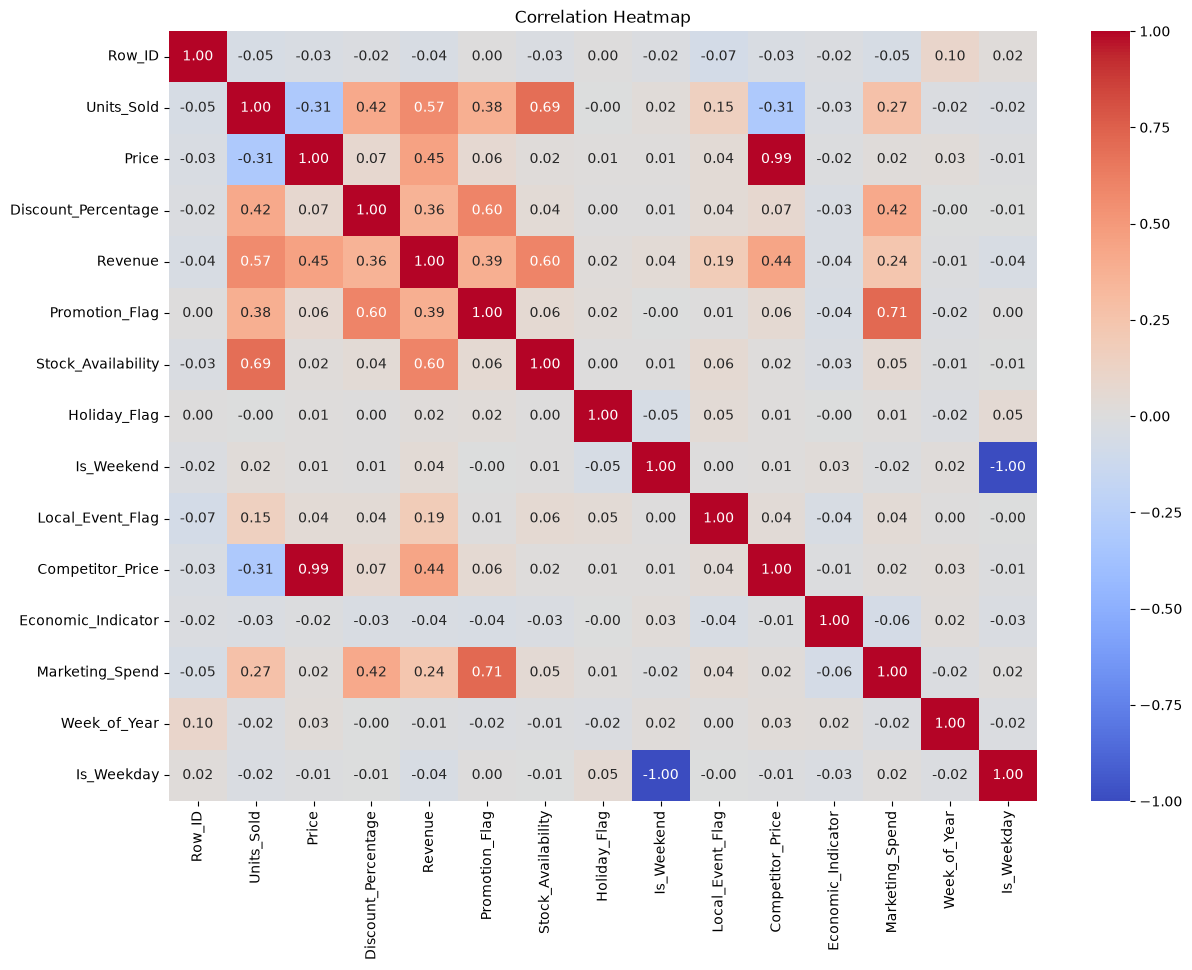

In [184]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [185]:
#Correlation with Units_Sold
units_sold_corr = (
    correlation_matrix["Units_Sold"]
    .sort_values(ascending=False)
)

print(units_sold_corr)

Units_Sold             1.000000
Stock_Availability     0.693741
Revenue                0.568104
Discount_Percentage    0.416296
Promotion_Flag         0.383766
Marketing_Spend        0.269368
Local_Event_Flag       0.153969
Is_Weekend             0.023689
Holiday_Flag          -0.000033
Week_of_Year          -0.020770
Is_Weekday            -0.023689
Economic_Indicator    -0.027352
Row_ID                -0.054543
Price                 -0.306506
Competitor_Price      -0.309005
Name: Units_Sold, dtype: float64


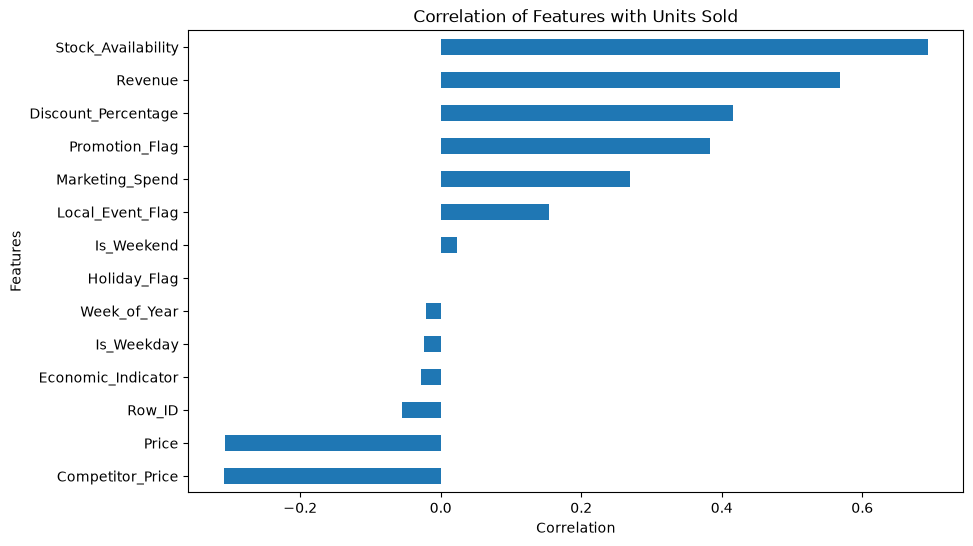

In [186]:
plt.figure(figsize=(10, 6))

units_sold_corr.drop("Units_Sold").sort_values().plot(
    kind="barh"
)

plt.title("Correlation of Features with Units Sold")
plt.xlabel("Correlation")
plt.ylabel("Features")


plt.show()

In [187]:
df["Date"] = pd.to_datetime(df["Date"])

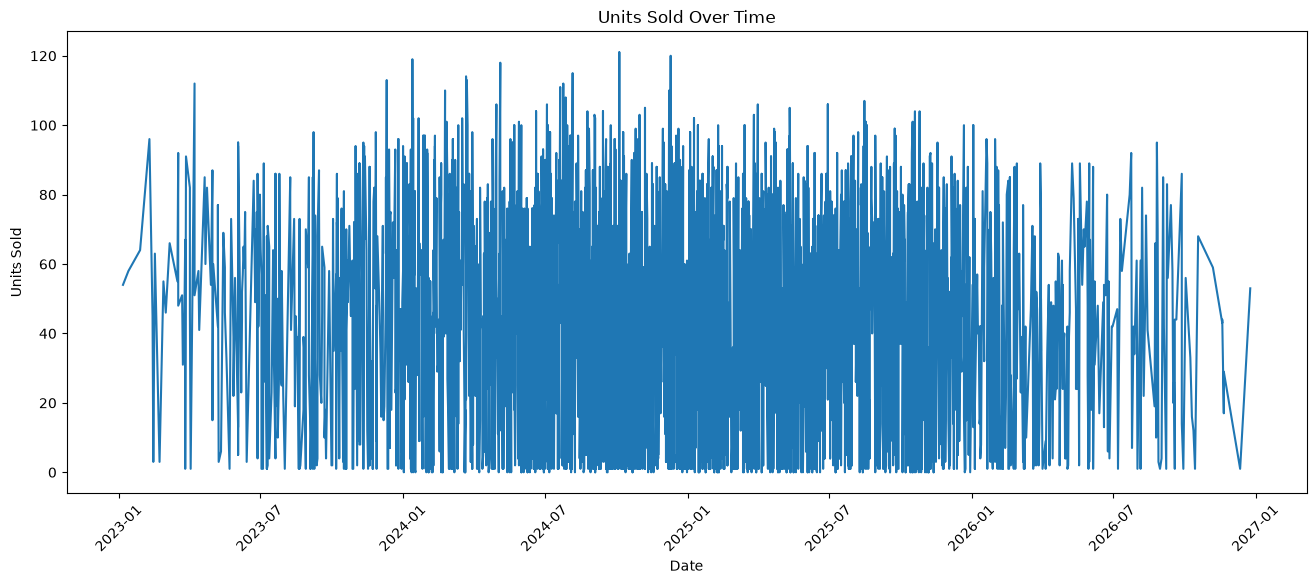

In [188]:
#Time-Based Analysis
plt.figure(figsize=(16, 6))

plt.plot(
    df["Date"],
    df["Units_Sold"]
)

plt.title("Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.show()

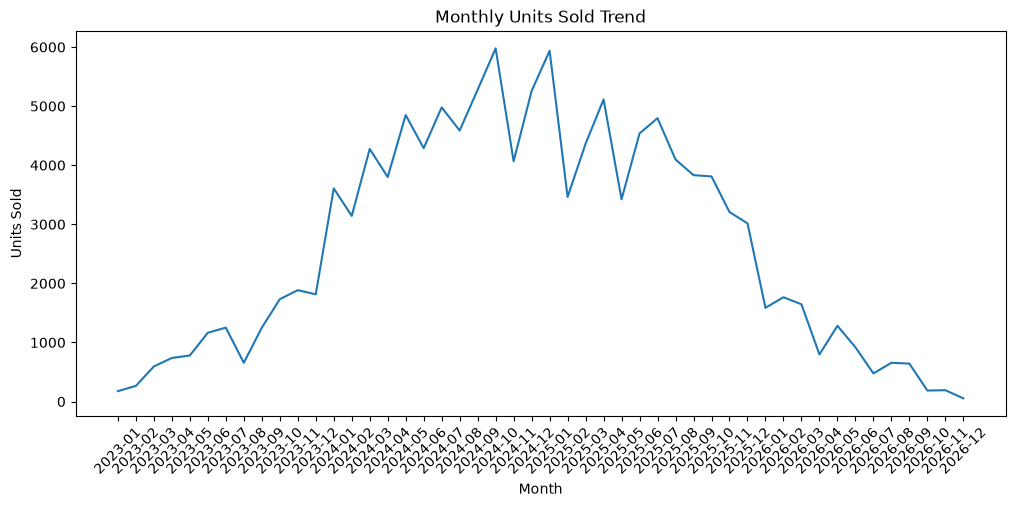

In [189]:
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Units_Sold'].sum()
 
plt.figure(figsize=(12,5))
 
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
 
plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

In [190]:
categorical_columns = [
    "Product_Name",
    "Category",
    "Store_Location",
    "Sales_Channel",
    "Customer_Segment",
    "Holiday_Name",
    "Season",
    "Weather"
]
 
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 Product_Name
<ArrowStringArray>
['Bluetooth Speaker',     'LED Desk Lamp',     'Running Shoes',
     'Notebook Pack',    'Wireless Mouse',          'Yoga Mat',
      'Coffee Maker',      'Office Chair']
Length: 8, dtype: str

 Category
<ArrowStringArray>
['Electronics',        'Home',     'Apparel',  'Stationery',      'Sports',
  'Appliances',   'Furniture']
Length: 7, dtype: str

 Store_Location
<ArrowStringArray>
['Chennai', 'Delhi', 'Bengaluru', 'Mumbai']
Length: 4, dtype: str

 Sales_Channel
<ArrowStringArray>
['Online', 'In-Store', 'Wholesale']
Length: 3, dtype: str

 Customer_Segment
<ArrowStringArray>
['Retail', 'Corporate', 'Wholesale']
Length: 3, dtype: str

 Holiday_Name
<ArrowStringArray>
['No Government Holiday',               'May Day',      'Independence Day',
        'Gandhi Jayanti',             'Christmas',              'New Year',
          'Republic Day']
Length: 7, dtype: str

 Season
<ArrowStringArray>
['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
Length: 4, d

Feature Engineering

In [191]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns)


Index(['Row_ID', 'Units_Sold', 'Price', 'Discount_Percentage', 'Revenue',
       'Promotion_Flag', 'Stock_Availability', 'Holiday_Flag', 'Is_Weekend',
       'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator',
       'Marketing_Spend', 'Week_of_Year', 'Is_Weekday'],
      dtype='str')


In [192]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location',
       'Day_of_Week', 'Month', 'Quarter', 'Holiday_Name', 'Season', 'Weather',
       'Sales_Channel', 'Customer_Segment'],
      dtype='str')


C:\Users\Nandhakumar\AppData\Local\Temp\ipykernel_7608\3603927628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [193]:
df["Date"] = pd.to_datetime(df["Date"])

In [194]:
print(df[["Date", "Units_Sold"]].head())

        Date  Units_Sold
0 2023-01-06          54
1 2023-01-13          58
2 2023-01-28          64
3 2023-02-09          96
4 2023-02-13          45


In [195]:
df["Year"] = df["Date"].dt.year

In [196]:
df["Month"] = df["Date"].dt.month

In [197]:
df["Day"] = df["Date"].dt.day

In [198]:
df["Day_of_Week"] = df["Date"].dt.dayofweek

In [199]:
df["Week_of_Year"] = df["Date"].dt.isocalendar().week.astype(int)

In [200]:
df["Quarter"] = df["Date"].dt.quarter

In [201]:
df["Is_Weekend"] = (
    df["Day_of_Week"] >= 5
).astype(int)

In [202]:
df["Is_Weekday"] = (
    df["Day_of_Week"] < 5
).astype(int)

In [203]:
df["Units_Sold_Lag_1"] = (
    df["Units_Sold"].shift(1)
)

In [204]:
df["Units_Sold_Lag_7"] = (
    df["Units_Sold"].shift(7)
)

In [205]:
df["Units_Sold_Lag_14"] = (
    df["Units_Sold"].shift(14)
)

In [206]:
df["Units_Sold_Lag_30"] = (
    df["Units_Sold"].shift(30)
)

In [207]:
df["Sales_Rolling_Mean_7"] = (
    df["Units_Sold"]
    .shift(1)
    .rolling(7)
    .mean()
)

In [208]:
df["Sales_Rolling_Mean_14"] = (
    df["Units_Sold"]
    .shift(1)
    .rolling(14)
    .mean()
)

In [209]:
df["Sales_Rolling_Mean_30"] = (
    df["Units_Sold"]
    .shift(1)
    .rolling(30)
    .mean()
)

In [210]:
df["Sales_Rolling_Max_7"] = (
    df["Units_Sold"]
    .shift(1)
    .rolling(7)
    .max()
)

In [211]:
df["Sales_Rolling_Min_7"] = (
    df["Units_Sold"]
    .shift(1)
    .rolling(7)
    .min()
)

In [212]:
df["Sales_Rolling_Std_7"] = (
    df["Units_Sold"]
    .shift(1)
    .rolling(7)
    .std()
)

In [213]:
df["Sales_Expanding_Mean"] = (
    df["Units_Sold"]
    .shift(1)
    .expanding()
    .mean()
)

In [214]:
df["Time_Index"] = np.arange(len(df))

In [215]:
df["Month_Sin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

In [216]:
df["Month_Cos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)

In [217]:
df["DayOfWeek_Sin"] = np.sin(
    2 * np.pi * df["Day_of_Week"] / 7
)

df["DayOfWeek_Cos"] = np.cos(
    2 * np.pi * df["Day_of_Week"] / 7
)

In [218]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location',
       'Holiday_Name', 'Season', 'Weather', 'Sales_Channel',
       'Customer_Segment'],
      dtype='str')


C:\Users\Nandhakumar\AppData\Local\Temp\ipykernel_7608\3603927628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


Categorical Encoding

In [219]:
# Onehot encoding

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [220]:
df.isnull().sum()

Row_ID                        0
Date                          0
Units_Sold                    0
Price                         0
Discount_Percentage           0
                             ..
Weather_Sunny                 0
Sales_Channel_Online          0
Sales_Channel_Wholesale       0
Customer_Segment_Retail       0
Customer_Segment_Wholesale    0
Length: 80, dtype: int64

In [221]:
df = df.dropna().reset_index(drop=True)

In [222]:
print(df.columns.tolist())

['Row_ID', 'Date', 'Units_Sold', 'Price', 'Discount_Percentage', 'Revenue', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Flag', 'Is_Weekend', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Marketing_Spend', 'Week_of_Year', 'Is_Weekday', 'Year', 'Day', 'Units_Sold_Lag_1', 'Units_Sold_Lag_7', 'Units_Sold_Lag_14', 'Units_Sold_Lag_30', 'Sales_Rolling_Mean_7', 'Sales_Rolling_Mean_14', 'Sales_Rolling_Mean_30', 'Sales_Rolling_Max_7', 'Sales_Rolling_Min_7', 'Sales_Rolling_Std_7', 'Sales_Expanding_Mean', 'Time_Index', 'Month_Sin', 'Month_Cos', 'DayOfWeek_Sin', 'DayOfWeek_Cos', 'Product_ID_P002', 'Product_ID_P003', 'Product_ID_P004', 'Product_ID_P005', 'Product_ID_P006', 'Product_ID_P007', 'Product_ID_P008', 'Product_Name_Coffee Maker', 'Product_Name_LED Desk Lamp', 'Product_Name_Notebook Pack', 'Product_Name_Office Chair', 'Product_Name_Running Shoes', 'Product_Name_Wireless Mouse', 'Product_Name_Yoga Mat', 'Category_Appliances', 'Category_

In [223]:
df.head()

,Row_ID,Date,Units_Sold,Price,Discount_Percentage,Revenue,Promotion_Flag,Stock_Availability,Day_of_Week,Month,...,Season_Summer,Season_Winter,Weather_Cloudy,Weather_Rainy,Weather_Stormy,Weather_Sunny,Sales_Channel_Online,Sales_Channel_Wholesale,Customer_Segment_Retail,Customer_Segment_Wholesale
0,31,2023-04-27,65,1472.373382,0,95704.27,1,1,3,4,...,True,False,True,False,False,False,False,False,True,False
1,32,2023-04-29,54,2278.772476,16,103365.12,1,1,5,4,...,True,False,False,False,False,False,False,False,False,True
2,34,2023-05-01,87,1376.231383,15,101772.31,1,1,0,5,...,True,False,False,False,False,True,False,True,False,True
3,33,2023-05-01,15,4711.335651,0,70670.03,0,1,0,5,...,True,False,False,False,False,True,True,False,False,True
4,35,2023-05-02,60,303.604164,0,18216.25,1,1,1,5,...,True,False,True,False,False,False,False,True,False,True


Separate Features and Target

In [224]:
y = df["Units_Sold"]

In [225]:
X = df.drop(columns=["Units_Sold"])

In [226]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2970, 79)
y shape: (2970,)


XGBoost Model Training

In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,mean_absolute_percentage_error,
    r2_score
)

In [228]:
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [229]:
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

X_train: (2079, 79)
X_val  : (445, 79)
X_test : (446, 79)
y_train: (2079,)
y_val  : (445,)
y_test : (446,)


In [230]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.01,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

In [231]:
for x in [X_train, X_test]:
    x['year']    = x['Date'].dt.year
    x['month']   = x['Date'].dt.month
    x['day']     = x['Date'].dt.day
    x['weekday'] = x['Date'].dt.weekday
    x.drop(columns=['Date'], inplace=True)


xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost Training Completed!")

XGBoost Training Completed!


In [232]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

xgb_model.fit(X_train, y_train)
y_val_pred = xgb_model.predict(X_val)

In [233]:
from sklearn.metrics import r2_score

val_r2 = r2_score(
    y_val,
    y_val_pred
)

print("Validation R²:", val_r2)
print("Validation R² %:", val_r2 * 100)

Validation R²: 0.9914301037788391
Validation R² %: 99.14301037788391


In [234]:
y_pred_xgb= xgb_model.predict(X_test)

In [235]:
import numpy as np

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    # Zero denominator avoid panna
    mask = denominator != 0

    smape_value = np.mean(
        np.abs(y_true[mask] - y_pred[mask]) /
        denominator[mask]
    ) * 100

    return smape_value

In [236]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,mean_absolute_percentage_error,r2_score
import numpy as np

xgb_mae = mean_absolute_error(
    y_val,
    y_val_pred
)

xgb_mse = mean_squared_error(
        y_val,
        y_val_pred
    )

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)
xgb_mape = mean_absolute_percentage_error(y_val, y_val_pred) * 100


xgb_smape = smape(
    y_val,
    y_val_pred
)

xgb_r2 = r2_score(
    y_val,
    y_val_pred
)

print("================================")
print("XGBoost Validation Performance")
print("================================")

print(f"MAE  : {xgb_mae:.2f}")
print(f"MSE : {xgb_mse:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print("MAPE :", xgb_mape, "%")
print("SMAPE :", f"{xgb_smape:.2f}%")
print(f"R²   : {xgb_r2:.4f}")
print(f"R² % : {xgb_r2 * 100:.2f}%")

XGBoost Validation Performance
MAE  : 1.67
MSE : 7.33
RMSE : 2.71
MAPE : 7347309117440000.0 %
SMAPE : 14.47%
R²   : 0.9914
R² % : 99.14%


LSTM Model Training

In [237]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [239]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    "Date"
).reset_index(drop=True)

In [240]:
target = "Units_Sold"
data = df[[target]].copy()

print(data.head())
print(data.shape)

   Units_Sold
0          65
1          54
2          87
3          15
4          60
(2970, 1)


In [241]:
n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data.iloc[:train_end]
val_data = data.iloc[train_end:val_end]
test_data = data.iloc[val_end:]

In [242]:
print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (2079, 1)
Validation: (445, 1)
Test: (446, 1)


In [243]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_data
)

val_scaled = scaler.transform(
    val_data
)

test_scaled = scaler.transform(
    test_data
)

In [244]:
time_steps = 30
def create_sequences(data, time_steps):
    
    X = []
    y = []
    
    for i in range(time_steps, len(data)):
        
        X.append(
            data[i-time_steps:i, 0]
        )
        
        y.append(
            data[i, 0]
        )
    
    return np.array(X), np.array(y)

In [245]:
X_train, y_train = create_sequences(
    train_scaled,
    time_steps
)

In [246]:
val_input = np.concatenate(
    [
        train_scaled[-time_steps:],
        val_scaled
    ]
)
X_val, y_val = create_sequences(
    val_input,
    time_steps
)

In [247]:
test_input = np.concatenate(
    [
        val_input[-time_steps:],
        test_scaled
    ]
)
X_test, y_test = create_sequences(
    test_input,
    time_steps
)

In [248]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2049, 30)
y_train: (2049,)
X_val: (445, 30)
y_val: (445,)
X_test: (446, 30)
y_test: (446,)


In [249]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_val = X_val.reshape(
    X_val.shape[0],
    X_val.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [250]:
print(X_train.shape)

(2049, 30, 1)


In [251]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(time_steps, 1)
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    Dense(32, activation="relu")
)

lstm_model.add(
    Dense(1)
)

c:\Users\Nandhakumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [252]:
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [253]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [254]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [255]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

In [256]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 0.0691 - mae: 0.2180 - val_loss: 0.0572 - val_mae: 0.2018 - learning_rate: 0.0010
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0618 - mae: 0.2090 - val_loss: 0.0571 - val_mae: 0.2024 - learning_rate: 0.0010
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0622 - mae: 0.2094 - val_loss: 0.0581 - val_mae: 0.2049 - learning_rate: 0.0010
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0622 - mae: 0.2101 - val_loss: 0.0615 - val_mae: 0.2123 - learning_rate: 0.0010
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0612 - mae: 0.2078 - val_loss: 0.0573 - val_mae: 0.2030 - learning_rate: 0.0010
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0609 - mae: 0.2074 - val_loss: 0.0590 - val_mae: 0.2071 - learning_rate: 0.0010
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0606 - mae: 0.2068 - val_loss: 0.0565 - val_mae: 0.2001 - learning_rate: 0.0010
Epoch 

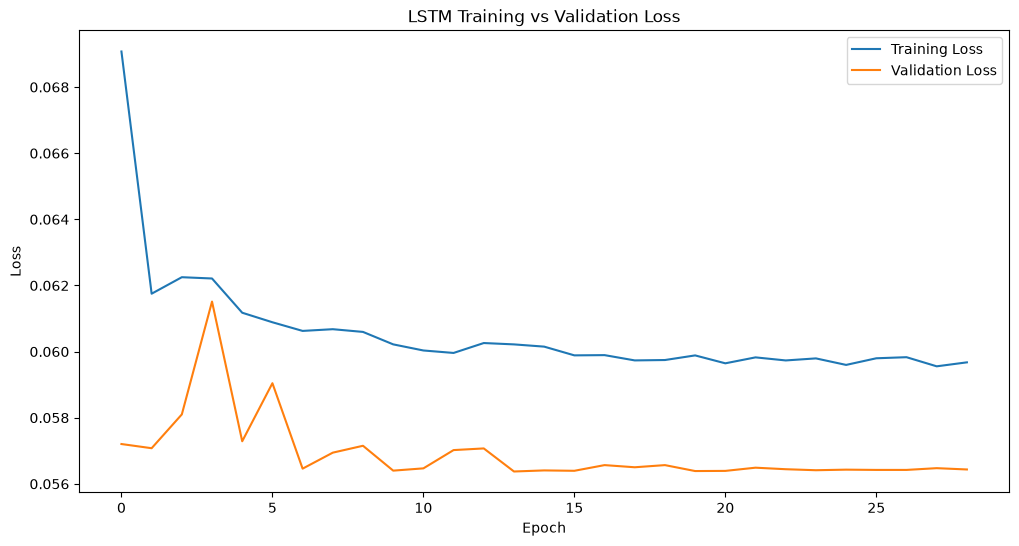

In [257]:
plt.figure(figsize=(12, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [258]:
y_val_pred_scaled = lstm_model.predict(
    X_val
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [259]:
y_val_actual = scaler.inverse_transform(
    y_val.reshape(-1, 1)
).flatten()

y_val_pred = scaler.inverse_transform(
    y_val_pred_scaled
).flatten()

In [260]:
LSTM_mae = mean_absolute_error(
    y_val_actual,
    y_val_pred
)

LSTM_rmse = np.sqrt(
    mean_squared_error(
        y_val_actual,
        y_val_pred
    )
)

LSTM_r2 = r2_score(
    y_val_actual,
    y_val_pred
)

In [261]:
print("LSTM VALIDATION EVALUATION")


print(f"MAE  : {LSTM_mae:.2f}")
print(f"RMSE : {LSTM_rmse:.2f}")
print(f"R²   : {LSTM_r2:.4f}")
print(f"R² % : {LSTM_r2 * 100:.2f}%")

LSTM VALIDATION EVALUATION
MAE  : 24.17
RMSE : 28.73
R²   : -0.0012
R² % : -0.12%


ARIMA Model Training

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Dataset
df = pd.read_excel("Sales_Forcasting_Dataset.xlsx")


# Date convert
df["Date"] = pd.to_datetime(df["Date"])


# Sort by Date
df = df.sort_values("Date").reset_index(drop=True)


# Select Sales column
sales = df["Units_Sold"].copy()


# Train-Test Split
train_size = int(len(sales) * 0.8)

train = sales.iloc[:train_size].reset_index(drop=True)
test = sales.iloc[train_size:].reset_index(drop=True)


print("Train Data:", len(train))
print("Test Data :", len(test))


# ARIMA Model
arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)


# Train ARIMA
arima_model_fit = arima_model.fit()


print("ARIMA Model Training Completed!")


# Prediction
arima_pred = arima_model_fit.forecast(
    steps=len(test)
)

arima_pred = pd.Series(
    arima_pred
).reset_index(drop=True)


# Evaluation
arima_mae = mean_absolute_error(
    test,
    arima_pred
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_pred
    )
)

arima_r2 = r2_score(
    test,
    arima_pred
)


print("\nARIMA Results")
print("----------------------")
print("MAE  :", arima_mae)
print("RMSE :", arima_rmse)
print("R2   :", arima_r2)
print("R2 % :", arima_r2 * 100)

Train Data: 2400
Test Data : 600
ARIMA Model Training Completed!

ARIMA Results
----------------------
MAE  : 24.554768865253727
RMSE : 28.818122960889873
R2   : -0.014630108645535822
R2 % : -1.4630108645535822


Prophet Model Training

In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Dataset
df = pd.read_excel("Sales_Forcasting_Dataset.xlsx")


# Date convert
df["Date"] = pd.to_datetime(df["Date"])


# Sort by Date
df = df.sort_values("Date").reset_index(drop=True)


# Prophet requires:
# ds = Date
# y  = Target
prophet_df = df[["Date", "Units_Sold"]].copy()

prophet_df = prophet_df.rename(
    columns={
        "Date": "ds",
        "Units_Sold": "y"
    }
)


# Train-Test Split
train_size = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:train_size].copy()
test = prophet_df.iloc[train_size:].copy()


print("Train Data:", len(train))
print("Test Data :", len(test))


# Create Prophet Model
prophet_model = Prophet()


# Train Model
prophet_model.fit(train)


print("Prophet Model Training Completed!")


# Future Dates for Test Period
future = test[["ds"]].copy()


# Prediction
forecast = prophet_model.predict(future)


# Predicted values
prophet_pred = forecast["yhat"].values


# Evaluation
prophet_mae = mean_absolute_error(
    test["y"],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        prophet_pred
    )
)

prophet_r2 = r2_score(
    test["y"],
    prophet_pred
)


print("\nProphet Results")
print("----------------------")
print("MAE  :", prophet_mae)
print("RMSE :", prophet_rmse)
print("R2   :", prophet_r2)
print("R2 % :", prophet_r2 * 100)

Train Data: 2400
Test Data : 600


09:45:10 - cmdstanpy - INFO - Chain [1] start processing
09:45:10 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Training Completed!

Prophet Results
----------------------
MAE  : 24.698970717917394
RMSE : 28.782470425829672
R2   : -0.012121148639161028
R2 % : -1.2121148639161028


CatBoost Model Training

In [264]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [265]:
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

In [266]:
X = df.drop(columns=["Units_Sold"])
y = df["Units_Sold"]

In [267]:
split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2400, 26)
X_test : (600, 26)
y_train: (2400,)
y_test : (600,)


In [268]:
X_train = X_train.select_dtypes(
    include=np.number
)

X_test = X_test.select_dtypes(
    include=np.number
)

print("Features used:", X_train.columns.tolist())

Features used: ['Row_ID', 'Price', 'Discount_Percentage', 'Revenue', 'Promotion_Flag', 'Stock_Availability', 'Holiday_Flag', 'Is_Weekend', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Marketing_Spend']


In [269]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

In [270]:
cat_model.fit(
    X_train,
    y_train
)

print("CatBoost Training Completed!")

CatBoost Training Completed!


In [271]:
y_pred_cat= cat_model.predict(
    X_test
)

print("CatBoost Prediction Completed!")

CatBoost Prediction Completed!


In [272]:
cat_mae = mean_absolute_error(
    y_test,
    y_pred_cat
)


cat_mse = mean_squared_error(
        y_test,
        y_pred_cat
    )

cat_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_cat
    )
)
cat_mape = mean_absolute_percentage_error(y_test, y_pred_cat) * 100

cat_smape = smape(
    y_test,
    y_pred_cat
)

cat_r2 = r2_score(
    y_test,
    y_pred_cat
)

In [273]:
print("================================")
print("CATBOOST MODEL EVALUATION")
print("================================")

print(f"MAE  : {cat_mae:.2f}")
print(f"MSE : {cat_mse:.2f}")
print(f"RMSE : {cat_rmse:.2f}")
print("MAPE :", cat_mape, "%")
print(f"SMAPE : {cat_smape:.2f}%")
print(f"R²   : {cat_r2:.4f}")
print(f"R² % : {cat_r2 * 100:.2f}%")

CATBOOST MODEL EVALUATION
MAE  : 2.13
MSE : 9.17
RMSE : 3.03
MAPE : 1.0512294323774824e+16 %
SMAPE : 19.41%
R²   : 0.9888
R² % : 98.88%


LightGBM Model Training

In [274]:
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,mean_absolute_percentage_error,r2_score

In [275]:
X = df.drop(columns=["Units_Sold"])
y = df["Units_Sold"]

split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2400, 26)
X_test: (600, 26)
y_train: (2400,)
y_test: (600,)


In [276]:
X = df.drop(columns=["Units_Sold"])
y = df["Units_Sold"]

split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2400, 26)
X_test: (600, 26)
y_train: (2400,)
y_test: (600,)


In [277]:
X_train = X_train.select_dtypes(include=np.number)
X_test = X_test.select_dtypes(include=np.number)

In [278]:
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

In [279]:
lgb_model.fit(
    X_train,
    y_train
)

print("LightGBM Training Completed!")

LightGBM Training Completed!


In [280]:
y_pred_lgb = lgb_model.predict(
    X_test
)

print("Prediction Completed!")

Prediction Completed!


In [281]:
mae = mean_absolute_error(
    y_test,
    y_pred_lgb
)


mse = mean_squared_error(
        y_test,
        y_pred_lgb
    )

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lgb
    )
)
mape = mean_absolute_percentage_error(y_test, y_pred_lgb) * 100


lgb_smape = smape(
    y_test,
    y_pred_lgb
)

r2 = r2_score(
    y_test,
    y_pred_lgb
)

In [282]:
print("================================")
print("LIGHTGBM MODEL EVALUATION")
print("================================")

print(f"MAE  : {mae:.2f}")
print(f"MSE :  {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print("MAPE :", mape, "%")
print(f"SMAPE : {lgb_smape:.2f}%")
print(f"R²   : {r2:.4f}")
print(f"R² % : {r2 * 100:.2f}%")

LIGHTGBM MODEL EVALUATION
MAE  : 2.06
MSE :  9.49
RMSE : 3.08
MAPE : 5401351379300605.0 %
SMAPE : 18.15%
R²   : 0.9884
R² % : 98.84%


Random Forest Model Training

In [283]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

In [284]:
X = df.drop(columns=["Units_Sold"])
y = df["Units_Sold"]

In [285]:
split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2400, 26)
X_test : (600, 26)
y_train: (2400,)
y_test : (600,)


In [286]:
X_train = X_train.select_dtypes(
    include=np.number
)

X_test = X_test.select_dtypes(
    include=np.number
)

In [287]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [288]:
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Training Completed!")

Random Forest Training Completed!


In [289]:
y_pred = rf_model.predict(
    X_test
)

print("Random Forest Prediction Completed!")

Random Forest Prediction Completed!


In [290]:
rf_mae = mean_absolute_error(
    y_test,
    y_pred
)

rf_mse = mean_squared_error(
        y_test,
        y_pred
    )

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)
rf_mape = mean_absolute_percentage_error(y_test, y_pred) * 100

rf_smape = smape(
    y_test,
    y_pred
)

rf_r2 = r2_score(
    y_test,
    y_pred
)

In [291]:
print("================================")
print("RANDOM FOREST MODEL EVALUATION")
print("================================")

print(f"MAE  : {rf_mae:.2f}")
print(f"MSE : {rf_mse:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print("MAPE :", mape, "%")
print(f"SMAPE : {rf_smape:.2f}%")
print(f"R²   : {rf_r2:.4f}")
print(f"R² % : {rf_r2 * 100:.2f}%")

RANDOM FOREST MODEL EVALUATION
MAE  : 3.10
MSE : 17.03
RMSE : 4.13
MAPE : 5401351379300605.0 %
SMAPE : 23.07%
R²   : 0.9792
R² % : 97.92%


  Model       MAE        MSE      RMSE          MAPE      SMAPE        R2
0   XGB  1.666619   7.334267  2.708185  7.347309e+15  14.474310  0.991430
1  CatB  2.132163   9.173724  3.028816  1.051229e+16  19.411744  0.988792
2  LGBM  2.063619   9.489071  3.080434  5.401351e+15  18.149525  0.988407
3    RF  3.095854  17.027910  4.126489  3.045854e+16  23.074078  0.979196


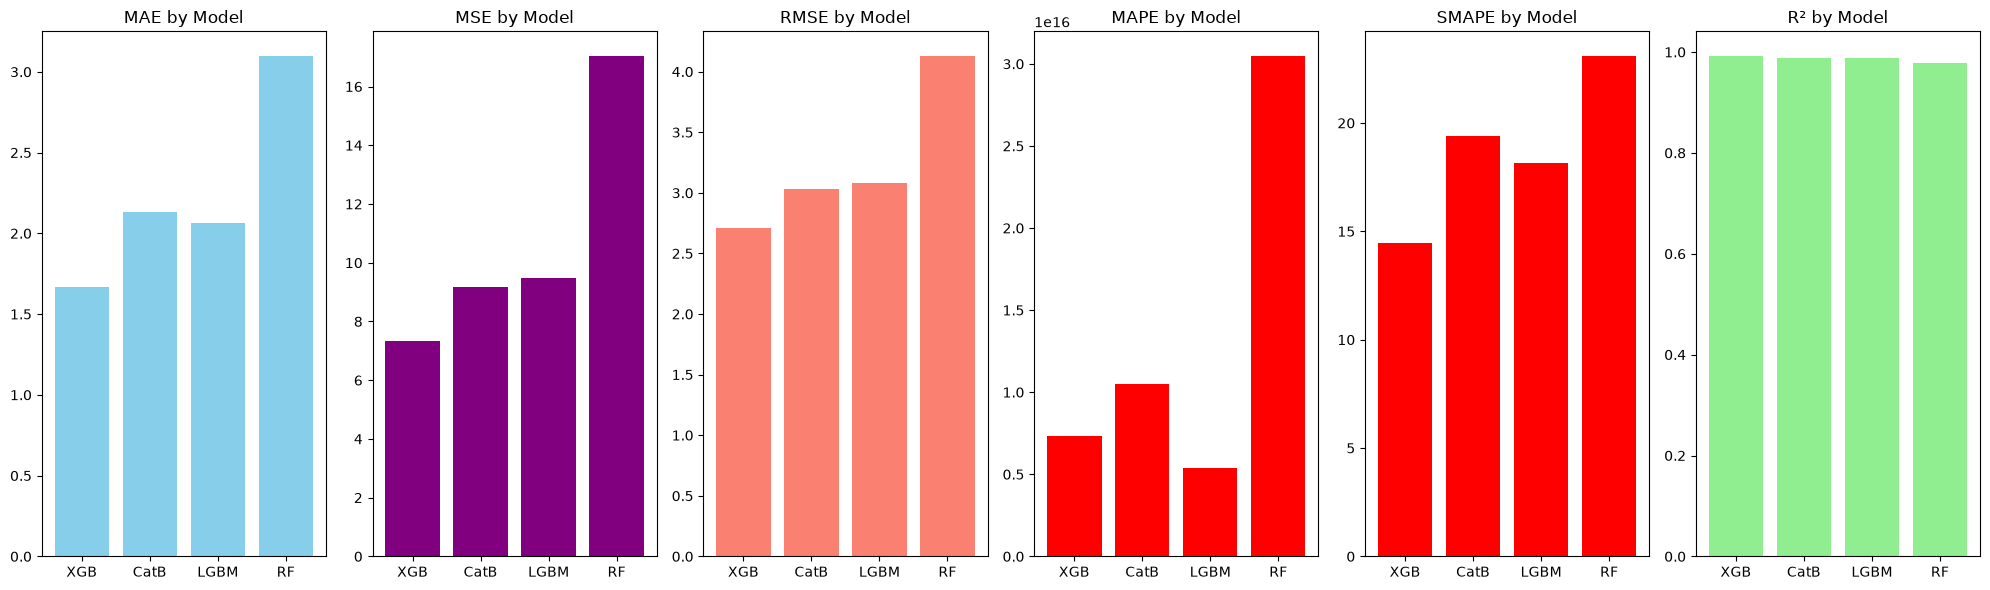

In [292]:
results = pd.DataFrame({
    "Model": ["XGB","CatB","LGBM","RF"],
    "MAE": [xgb_mae,cat_mae,mae,rf_mae ],
    "MSE": [xgb_mse,cat_mse,mse,rf_mse],
    "RMSE": [xgb_rmse,cat_rmse,rmse,rf_rmse],
    "MAPE":[xgb_mape,cat_mape,mape,rf_mape],
    "SMAPE":[xgb_smape,cat_smape,lgb_smape,rf_smape],
    "R2": [xgb_r2,cat_r2,r2,rf_r2 ]
})
 
print(results)
 
fig, axes = plt.subplots(1, 6, figsize=(20,6))
 
axes[0].bar(results["Model"], results["MAE"], color="skyblue")
axes[0].set_title("MAE by Model")

axes[1].bar(results["Model"], results["MSE"], color="purple")
axes[1].set_title("MSE by Model")
 
axes[2].bar(results["Model"], results["RMSE"], color="salmon")
axes[2].set_title("RMSE by Model")

axes[3].bar(results["Model"], results["MAPE"], color="red")
axes[3].set_title("MAPE by Model")

axes[4].bar(results["Model"], results["SMAPE"], color="red")
axes[4].set_title("SMAPE by Model")

axes[5].bar(results["Model"], results["R2"], color="lightgreen")
axes[5].set_title("R\u00b2 by Model")
 
plt.tight_layout()
plt.show()

Retraining

In [293]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [294]:
# ==========================================
# FINAL XGBOOST RETRAINING
# ==========================================

from xgboost import XGBRegressor

# Train + Validation combine
X_retrain = pd.concat(
    [X_train, X_val],
    axis=0
).reset_index(drop=True)

y_retrain = pd.concat(
    [y_train, y_val],
    axis=0
).reset_index(drop=True)

print("Retraining Data")
print("----------------------")
print("X_retrain:", X_retrain.shape)
print("y_retrain:", y_retrain.shape)


# Final XGBoost Model
final_xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.01,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)


# Retraining
final_xgb_model.fit(
    X_retrain,
    y_retrain
)

print("\n================================")
print("FINAL XGBOOST RETRAINING DONE")
print("================================")

Retraining Data
----------------------
X_retrain: (2400, 12)
y_retrain: (2400,)

FINAL XGBOOST RETRAINING DONE


In [295]:
# ==========================================
# FINAL TEST PREDICTION
# ==========================================

y_test_pred_xgb = final_xgb_model.predict(
    X_test
)

print("Final XGBoost prediction completed!")

Final XGBoost prediction completed!


In [296]:
# ==========================================
# FINAL XGBOOST PERFORMANCE
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

final_xgb_mae = mean_absolute_error(
    y_test,
    y_test_pred_xgb
)

final_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_xgb
    )
)

final_xgb_mape = mean_absolute_percentage_error(
    y_test,
    y_test_pred_xgb
) * 100

final_xgb_r2 = r2_score(
    y_test,
    y_test_pred_xgb
)

print("====================================")
print("FINAL XGBOOST TEST PERFORMANCE")
print("====================================")

print(f"MAE  : {final_xgb_mae:.2f}")
print(f"RMSE : {final_xgb_rmse:.2f}")
print(f"MAPE : {final_xgb_mape:.2f}%")
print(f"R²   : {final_xgb_r2:.4f}")
print(f"R² % : {final_xgb_r2 * 100:.2f}%")

FINAL XGBOOST TEST PERFORMANCE
MAE  : 1.80
RMSE : 2.84
MAPE : 6232562519244800.00%
R²   : 0.9902
R² % : 99.02%


In [297]:
# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

comparison_xgb = pd.DataFrame({
    "Actual_Units_Sold": y_test.values,
    "Predicted_Units_Sold": y_test_pred_xgb
})

print(comparison_xgb.head(20))

    Actual_Units_Sold  Predicted_Units_Sold
0                  62             71.029778
1                  85             84.952576
2                  51             53.851891
3                  58             59.345798
4                  14             15.154134
5                   6              6.537644
6                   1              1.246805
7                  23             25.547266
8                  43             42.224297
9                  81             76.098724
10                 31             31.018229
11                  1              0.852060
12                  2              1.418835
13                  0              0.252330
14                  2              2.076542
15                 62             60.156483
16                 64             63.356625
17                 59             70.372383
18                 91             87.762146
19                  6              5.065820


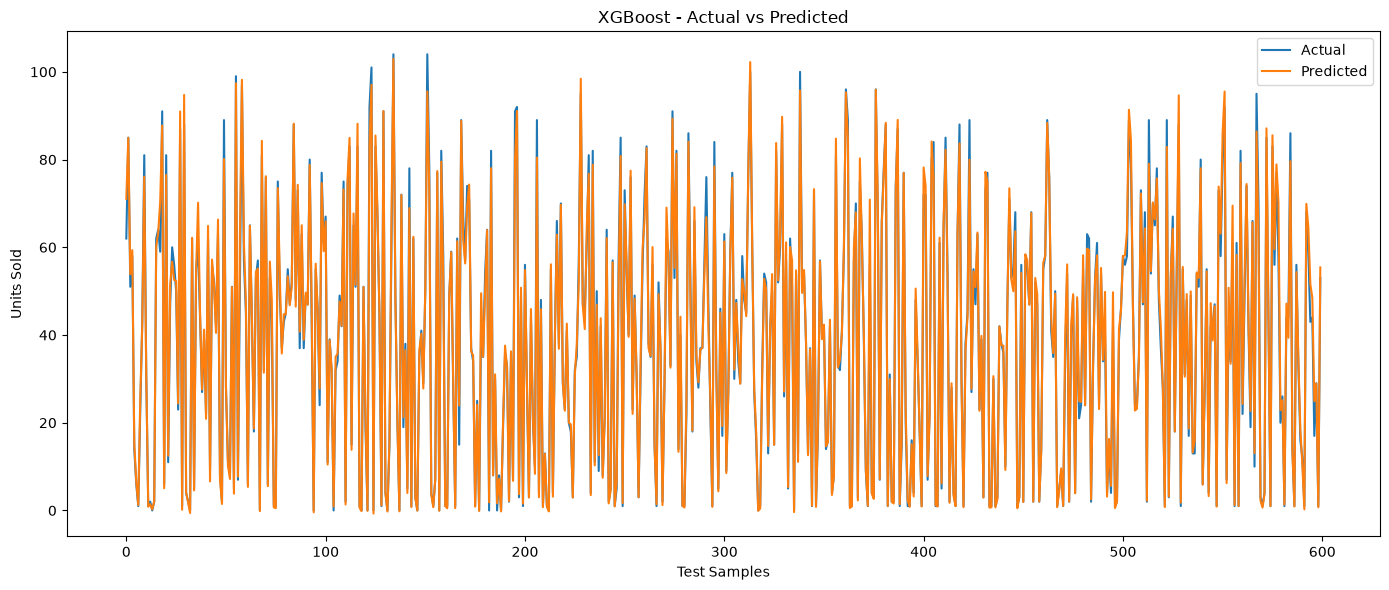

In [298]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_xgb["Actual_Units_Sold"],
    label="Actual"
)

plt.plot(
    comparison_xgb["Predicted_Units_Sold"],
    label="Predicted"
)

plt.title("XGBoost - Actual vs Predicted")

plt.xlabel("Test Samples")
plt.ylabel("Units Sold")

plt.legend()
plt.tight_layout()
plt.show()

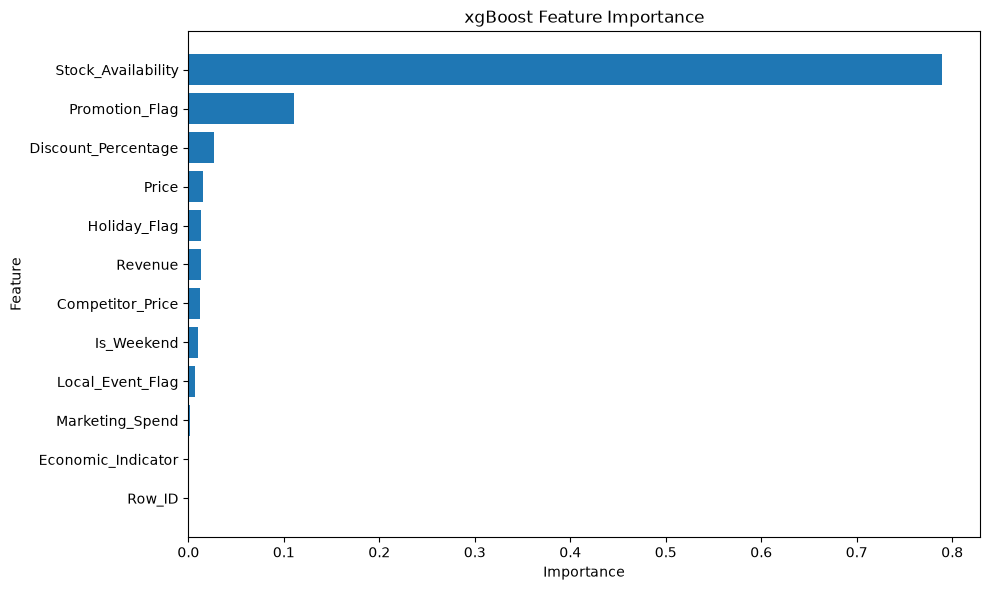

In [299]:
feature_importance = pd.DataFrame({
    "Feature": X_retrain.columns,
    "Importance": final_xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "xgBoost Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [300]:
df["Date"] = pd.to_datetime(
    df["Date"]
)

last_date = df["Date"].max()

future_dates = pd.date_range(

    start=last_date + pd.Timedelta(days=1),

    periods=730,

    freq="D"
)

future_df = pd.DataFrame({

    "Date": future_dates

})

print(
    future_df.head()
)

print(
    future_df.tail()
)

        Date
0 2026-12-26
1 2026-12-27
2 2026-12-28
3 2026-12-29
4 2026-12-30
          Date
725 2028-12-20
726 2028-12-21
727 2028-12-22
728 2028-12-23
729 2028-12-24


In [301]:
future_df["Year"] = (
    future_df["Date"].dt.year
)

future_df["Month"] = (
    future_df["Date"].dt.month
)

future_df["Day"] = (
    future_df["Date"].dt.day
)

future_df["Day_of_Week"] = (
    future_df["Date"].dt.dayofweek
)

future_df["Quarter"] = (
    future_df["Date"].dt.quarter
)

future_df["Week_of_Year"] = (
    future_df["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

In [302]:
future_df["Is_Weekend"] = (
    future_df["Day_of_Week"] >= 5
).astype(int)

future_df["Is_Weekday"] = (
    future_df["Day_of_Week"] < 5
).astype(int)

In [303]:
future_df["Month_Sin"] = np.sin(
    2 * np.pi *
    future_df["Month"] / 12
)

future_df["Month_Cos"] = np.cos(
    2 * np.pi *
    future_df["Month"] / 12
)

future_df["DayOfWeek_Sin"] = np.sin(
    2 * np.pi *
    future_df["Day_of_Week"] / 7
)

future_df["DayOfWeek_Cos"] = np.cos(
    2 * np.pi *
    future_df["Day_of_Week"] / 7
)

In [304]:
future_X = future_df.drop(
    columns=["Date"]
)

future_X = future_X.select_dtypes(
    include=np.number
)

future_X = future_X.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [305]:
future_prediction = final_xgb_model.predict(
    future_X
)

In [306]:
future_df["Predicted_Units_Sold"] = (
    future_prediction
)

print(
    future_df.head(20)
)

         Date  Year  Month  Day  Day_of_Week  Quarter  Week_of_Year  \
0  2026-12-26  2026     12   26            5        4            52   
1  2026-12-27  2026     12   27            6        4            52   
2  2026-12-28  2026     12   28            0        4            53   
3  2026-12-29  2026     12   29            1        4            53   
4  2026-12-30  2026     12   30            2        4            53   
5  2026-12-31  2026     12   31            3        4            53   
6  2027-01-01  2027      1    1            4        1            53   
7  2027-01-02  2027      1    2            5        1            53   
8  2027-01-03  2027      1    3            6        1            53   
9  2027-01-04  2027      1    4            0        1             1   
10 2027-01-05  2027      1    5            1        1             1   
11 2027-01-06  2027      1    6            2        1             1   
12 2027-01-07  2027      1    7            3        1             1   
13 202

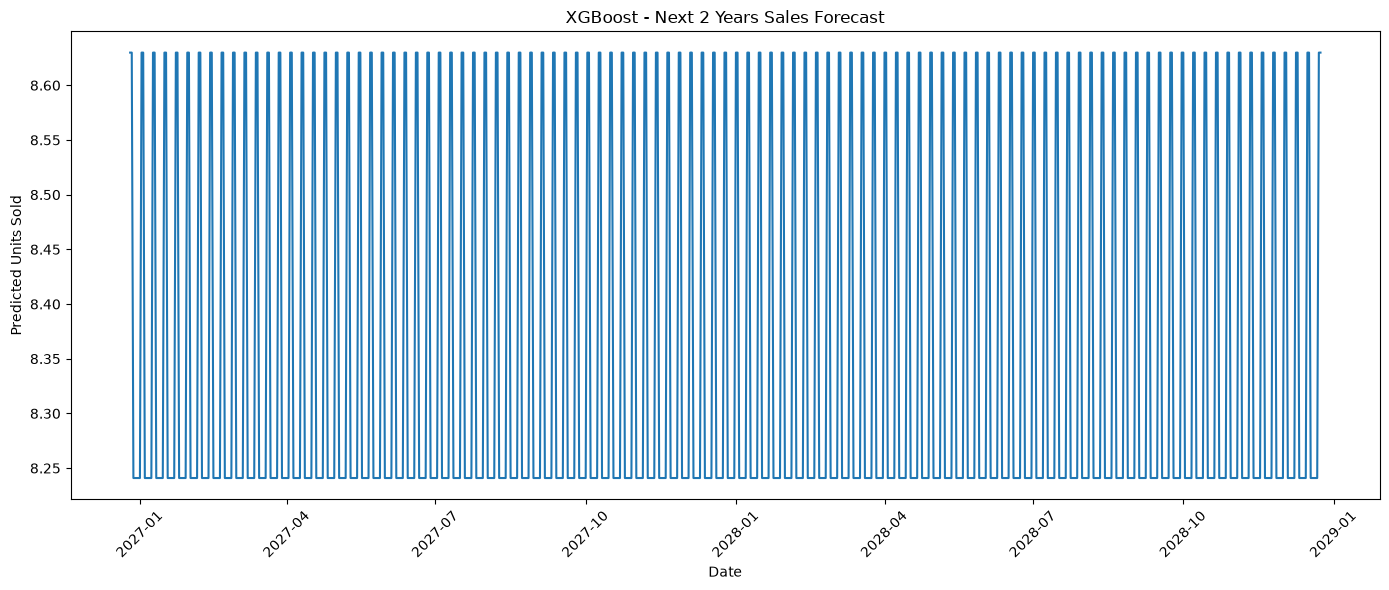

In [307]:
plt.figure(figsize=(14, 6))

plt.plot(
    future_df["Date"],
    future_df["Predicted_Units_Sold"]
)

plt.title(
    "XGBoost - Next 2 Years Sales Forecast"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Predicted Units Sold"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [308]:
future_df.to_excel(
    "xgBoost_2_year_sales_forecast.xlsx",
    index=False
)

print(
    "2-Year Forecast Saved Successfully!"
)

2-Year Forecast Saved Successfully!


In [309]:
import joblib

In [310]:
import joblib

joblib.dump(
    final_xgb_model,
    "final_xgboost_sales_model.pkl"
)

print("Final XGBoost model saved successfully!")

Final XGBoost model saved successfully!


In [311]:
import pickle

# Save exact feature columns used during training
feature_columns = X_train.columns.tolist()

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [312]:
import pickle
from datetime import datetime

# Deployment history file
deployment_history_file = "deployment_history.pkl"

# Existing history
try:
    with open(deployment_history_file, "rb") as f:
        deployment_history = pickle.load(f)
except FileNotFoundError:
    deployment_history = []

# Current XGBoost deployment details
deployment_record = {
    "model_name": "XGBoost",
    "model_file": "final_xgboost_sales_model.pkl",
    "feature_file": "xgboost_feature_columns.pkl",
    "deployment_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "status": "Deployed"
}

# Add current deployment
deployment_history.append(deployment_record)

# Save deployment history
with open(deployment_history_file, "wb") as f:
    pickle.dump(deployment_history, f)

print("XGBoost deployment history saved successfully!")
print("File:", deployment_history_file)

XGBoost deployment history saved successfully!
File: deployment_history.pkl
